# I. Khai báo thư viện
**Mục đích:**  
Phần này khai báo các thư viện cần thiết cho quá trình khám phá dữ liệu, bao gồm xử lý dữ liệu dạng bảng, tính toán số học, trực quan hóa biểu đồ và hiển thị kết quả trong notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML
from collections import Counter

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split

plt.style.use("default")
sns.set_theme(style="whitegrid")
# Khai báo biến output
EDA_OUTPUT_DIR = "/kaggle/working/eda_outputs"
os.makedirs(EDA_OUTPUT_DIR, exist_ok=True)

display(HTML("<span style = 'color: blue; font-weight:bold;'> Libraries are ready for working</span>"))

# II. EDA - TÌM HIỂU VÀ PHÂN TÍCH BỘ DỮ LIỆU
## II.1. Xác định vị trí bộ dữ liệu trên Kaggle
**Mục đích:**  
Cell này dùng để liệt kê các file dữ liệu có trong thư mục `/kaggle/input`, từ đó xác định chính xác đường dẫn đến file dữ liệu WM-811K.

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/quangjames/wm-811k/LSWMD.pkl


## II.2. Đọc bộ dữ liệu WM-811K

**Mục đích:**  
Cell này đọc file dữ liệu `LSWMD.pkl` của bộ WM-811K vào DataFrame để phục vụ quá trình khám phá dữ liệu.


In [3]:
# Load the dataset
DATA_PATH = "../input/datasets/quangjames/wm-811k/LSWMD.pkl"
df = pd.read_pickle(DATA_PATH)
display(HTML("<span style = 'color: blue; font-weight:bold;'> The dataset is ready for working</span>"))

**Nhận xét:**  
Bộ dữ liệu WM-811K đã được đọc thành công. Đây là bộ dữ liệu wafer map quy mô lớn, được sử dụng phổ biến trong các nghiên cứu phân loại lỗi wafer bán dẫn. Các bước tiếp theo sẽ kiểm tra cấu trúc dữ liệu, tình trạng nhãn và mức độ mất cân bằng lớp.

## II.3. Kiểm tra cấu trúc tổng quan của dữ liệu

**Mục đích:**  
Phần này kiểm tra thông tin tổng quan của DataFrame, bao gồm số lượng dòng, số lượng cột, kiểu dữ liệu của từng cột và số lượng giá trị thiếu.


In [4]:
# Thể hiện thông tin tổng quan của WM-811K dataset
display(HTML("<span style = 'color: blue; font-weight:bold;'> Dataset overview</span>"))
df.info()

display(HTML("<span style = 'color: blue; '> Missing values:</span>"))
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
dtype: int64


**Nhận xét:**  
Kết quả cho thấy bộ dữ liệu có quy mô lớn với tổng cộng **811,457 mẫu**. Các cột quan trọng phục vụ bài toán phân loại gồm `waferMap`, `dieSize`, `trianTestLabel` và `failureType`.

Trong đó, `waferMap` chứa bản đồ wafer, `failureType` chứa nhãn loại lỗi, còn `trianTestLabel` thể hiện nhãn chia tập huấn luyện/kiểm thử gốc của dataset. Tuy nhiên, nhãn trong các cột này đang được lưu dưới dạng mảng `numpy array`, do đó cần được chuẩn hóa trước khi phân tích và huấn luyện mô hình.

## II.4. Quan sát một số mẫu dữ liệu ban đầu

**Mục đích:**  
Cell này hiển thị một số dòng đầu và cuối của bộ dữ liệu nhằm quan sát trực tiếp cấu trúc từng mẫu dữ liệu.


In [5]:
# Xem dữ liệu mẫu của 5 mẫu đầu tiên và 5 mẫu cuối cùng để nhận diện và đánh giá cơ bản về dữ liệu
display(df.head())
display(df.tail())

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],[[Edge-Ring]]
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],[[Edge-Loc]]
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],[[Edge-Ring]]
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],[]
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],[]


**Nhận xét:**  
Kết quả quan sát cho thấy mỗi mẫu dữ liệu gồm một wafer map dạng ma trận hai chiều, thông tin kích thước die, mã lot, chỉ số wafer và nhãn lỗi. Đáng chú ý, cột `failureType` và `trianTestLabel` không phải chuỗi đơn mà là các mảng, ví dụ `[[none]]`, `[[Training]]` hoặc mảng rỗng `[]`.

Điều này cho thấy cần có bước chuẩn hóa nhãn để chuyển dữ liệu từ dạng mảng sang dạng chuỗi đơn, đồng thời xử lý các trường hợp không có nhãn.

## II.5. Chuẩn hóa nhãn dữ liệu

**Mục đích:**  
Cell này chuẩn hóa các nhãn trong cột `failureType` và `trianTestLabel` từ dạng mảng `numpy array` sang dạng chuỗi đơn để thuận tiện cho việc thống kê và xử lý tiếp theo.

**Thực hiện:**  
Hàm `extract_label()` được xây dựng để xử lý các trường hợp: mảng rỗng, giá trị thiếu, chuỗi rỗng và giá trị hợp lệ. Sau đó, nhãn lỗi được lưu vào cột `failure_label`, phiên bản chuẩn hóa chữ thường được lưu vào `failure_label_clean`, và nhãn train/test gốc được lưu vào `train_test_label`.

In [6]:
def extract_label(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return None
        x = x.flatten()[0]

    if pd.isna(x):
        return None

    x = str(x).strip()
    if x == "" or x.lower() in ["nan", "null"]:
        return None

    return x

df["failure_label"] = df["failureType"].apply(extract_label)
df["failure_label_clean"] = df["failure_label"].apply(
    lambda x: None if x is None else str(x).strip().lower()
)

df["train_test_label"] = df["trianTestLabel"].apply(extract_label)

display(df[[
    "waferMap", "dieSize", "lotName", "waferIndex",
    "trianTestLabel", "train_test_label",
    "failureType", "failure_label", "failure_label_clean"
]].head())
display(df[[
    "waferMap", "dieSize", "lotName", "waferIndex",
    "trianTestLabel", "train_test_label",
    "failureType", "failure_label", "failure_label_clean"
]].tail())

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,train_test_label,failureType,failure_label,failure_label_clean
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],Training,[[none]],none,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],Training,[[none]],none,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],Training,[[none]],none,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],Training,[[none]],none,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],Training,[[none]],none,none


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,train_test_label,failureType,failure_label,failure_label_clean
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],Test,[[Edge-Ring]],Edge-Ring,edge-ring
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],Test,[[Edge-Loc]],Edge-Loc,edge-loc
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],Test,[[Edge-Ring]],Edge-Ring,edge-ring
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],None,[],None,None
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],None,[],None,None


**Nhận xét:**  
Sau khi chuẩn hóa, các nhãn lỗi như `none`, `Edge-Ring`, `Edge-Loc` được chuyển về dạng chuỗi dễ xử lý hơn. Cột `failure_label_clean` giúp thống nhất cách viết nhãn bằng chữ thường, hạn chế sai lệch khi thống kê do khác biệt chữ hoa/chữ thường.

Bước này là cần thiết vì nếu không chuẩn hóa nhãn, việc đếm số lượng mẫu theo lớp hoặc lọc mẫu có nhãn có thể bị sai lệch.

**Trực quan hóa dữ liệu đang được chia nhãn train/ test từ dữ liệu gốc**
Tính toán và phân cụm bộ dữ liệu theo:
None label: mẫu không có nhãn, không dùng cho phân loại 9 lớp.
none label: lớp none, tức wafer không lỗi, vẫn là nhãn hợp lệ.
Failure labels: tổng các lớp lỗi còn lại.

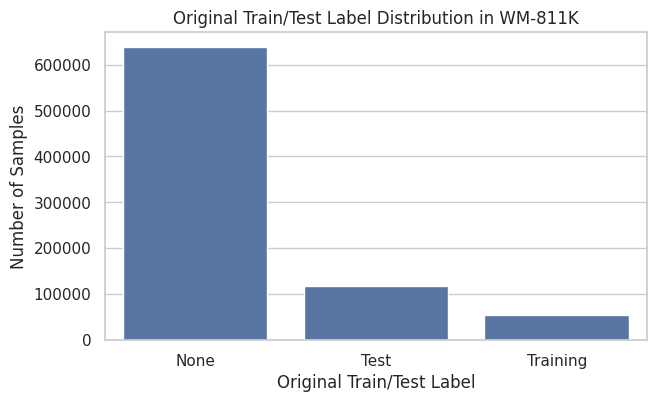

train_test_label
None        638507
Test        118595
Training     54355
Name: count, dtype: int64

In [7]:
# Trực quan hóa dữ liệu đang được được chia nhãn train/ test từ dữ liệu gốc
train_test_counts = df["train_test_label"].value_counts(dropna=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=train_test_counts.index.astype(str), y=train_test_counts.values)
plt.title("Original Train/Test Label Distribution in WM-811K")
plt.xlabel("Original Train/Test Label")
plt.ylabel("Number of Samples")
plt.savefig(
    f"{EDA_OUTPUT_DIR}/original_train_test_label_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

train_test_counts

## II.6. Phân nhóm mẫu không nhãn, mẫu không lỗi và mẫu lỗi

**Mục đích:**  
Cell này phân chia toàn bộ dataset thành ba nhóm chính: mẫu không có nhãn, mẫu có nhãn `none` biểu diễn wafer không lỗi, và mẫu thuộc các lớp lỗi.

**Thực hiện:**  
Dữ liệu được phân thành:
- `None label (unlabeled)`: mẫu không có nhãn, không dùng cho bài toán phân loại 9 lớp.
- `none label (normal/no defect)`: mẫu wafer không lỗi, là một lớp hợp lệ trong bài toán phân loại.
- `Failure labels (defect classes)`: tổng các mẫu thuộc 8 lớp lỗi còn lại.

In [8]:
# Chuẩn hóa nhãn về dạng chữ thường để tránh lệch do 'None', 'none', khoảng trắng...
df["failure_label_clean"] = df["failure_label"].apply(
    lambda x: None if x is None else str(x).strip().lower()
)

none_label_count = df["failure_label_clean"].isna().sum()
normal_none_count = (df["failure_label_clean"] == "none").sum()
failure_count = df[
    df["failure_label_clean"].notna() &
    (df["failure_label_clean"] != "none")
].shape[0]

summary_counts = pd.DataFrame({
    "group": [
        "None label (unlabeled)",
        "none label (normal/no defect)",
        "Failure labels (defect classes)"
    ],
    "count": [
        none_label_count,
        normal_none_count,
        failure_count
    ]
})

summary_counts["percentage"] = (
    summary_counts["count"] / summary_counts["count"].sum() * 100
).round(2)
summary_counts.to_csv(f"{EDA_OUTPUT_DIR}/label_availability_summary.csv", index=False)
summary_counts

,group,count,percentage
0,None label (unlabeled),638507,78.69
1,none label (normal/no defect),147431,18.17
2,Failure labels (defect classes),25519,3.14


Trực quan hóa phân bổ dữ liệu giữ mẫu không nhãn, có nhãn không lỗi và tổng nhãn lỗi

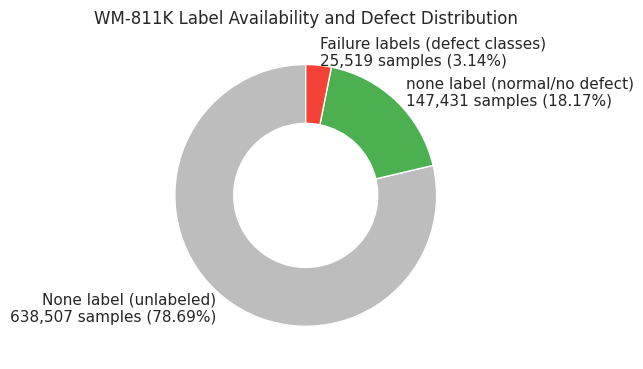

In [9]:
# Trực quan hóa phân bỗ dữ liệu giữ mẫu không nhãn, có nhãn không lỗi và tổng nhãn lỗi

plt.figure(figsize=(6, 6))

colors = ["#bdbdbd", "#4CAF50", "#F44336"]

wedges, texts = plt.pie(
    summary_counts["count"],
    labels=[
        f"{row['group']}\n{row['count']:,} samples ({row['percentage']}%)"
        for _, row in summary_counts.iterrows()
    ],
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1, "width": 0.45}
)

plt.title("WM-811K Label Availability and Defect Distribution")
plt.tight_layout()
plt.savefig(
    f"{EDA_OUTPUT_DIR}/original_defect_label_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Nhận xét:**  
Kết quả cho thấy trong tổng số **811,457 mẫu**, có **638,507 mẫu không có nhãn**, chiếm khoảng **78.69%** toàn bộ dữ liệu. Số mẫu có nhãn `none`, tức wafer không lỗi, là **147,431 mẫu**, chiếm khoảng **18.17%**. Tổng số mẫu thuộc các lớp lỗi là **25,519 mẫu**, chiếm khoảng **3.14%**.

Điều này cho thấy mặc dù WM-811K là bộ dữ liệu rất lớn, số mẫu thực sự có thể sử dụng cho bài toán phân loại có giám sát chỉ là một phần nhỏ. Do đó, trong phạm vi đề tài, các mẫu không có nhãn sẽ được loại bỏ, chỉ giữ lại các mẫu có nhãn để xây dựng bài toán phân loại 9 lớp.

## II.7. Trích xuất tập dữ liệu có nhãn

**Mục đích:**  
Cell này loại bỏ các mẫu không có nhãn và tạo tập dữ liệu `labeled_df` phục vụ bài toán phân loại 9 lớp.

**Thực hiện:**  
Chỉ các mẫu có `failure_label_clean` khác rỗng được giữ lại. Tập dữ liệu này bao gồm 8 lớp lỗi và lớp `none`.

In [10]:
# Keep only labeled samples for 9-class classification

labeled_df = df[df["failure_label_clean"].notna()].copy()

print("Total samples:", len(df))
print("Labeled samples for classification:", len(labeled_df))
print("Unlabeled samples removed:", none_label_count)

Total samples: 811457
Labeled samples for classification: 172950
Unlabeled samples removed: 638507


**Nhận xét:**  
Sau khi loại bỏ các mẫu không có nhãn, số mẫu còn lại dùng cho bài toán phân loại là **172,950 mẫu**. Đây là tập dữ liệu chính sẽ được sử dụng cho các bước tiền xử lý, chia tập train/validation/test và huấn luyện mô hình.

Việc xác định rõ phạm vi dữ liệu sử dụng giúp tránh nhầm lẫn giữa mẫu không có nhãn và lớp `none`. Trong bài toán này, `none` là một lớp hợp lệ, biểu diễn wafer không lỗi.

## II.8. Phân bố số lượng mẫu theo từng lớp

**Mục đích:**  
Cell này thống kê số lượng mẫu của từng lớp trong tập dữ liệu có nhãn nhằm đánh giá mức độ mất cân bằng lớp.

**Thực hiện:**  
Sử dụng `value_counts()` để đếm số mẫu theo `failure_label_clean`, sau đó trực quan hóa bằng biểu đồ cột.

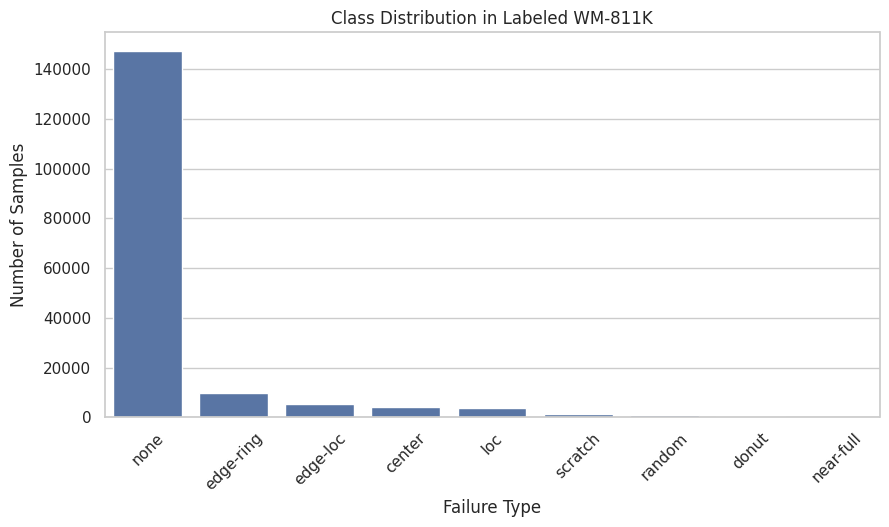

failure_label_clean
none         147431
edge-ring      9680
edge-loc       5189
center         4294
loc            3593
scratch        1193
random          866
donut           555
near-full       149
Name: count, dtype: int64

In [11]:
# Trực quan hóa việc phân bổ của các lớp nhãn
class_counts = labeled_df["failure_label_clean"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=45)
plt.title("Class Distribution in Labeled WM-811K")
plt.xlabel("Failure Type")
plt.ylabel("Number of Samples")
plt.savefig(
    f"{EDA_OUTPUT_DIR}/failure_label_clean_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
class_counts.to_csv(f"{EDA_OUTPUT_DIR}/class_counts.csv")
class_counts

**Nhận xét:**  
Kết quả cho thấy phân bố lớp trong tập dữ liệu có nhãn bị mất cân bằng nghiêm trọng. Lớp `none` có **147,431 mẫu**, chiếm phần lớn dữ liệu. Trong khi đó, một số lớp lỗi có số lượng rất thấp như `near-full` chỉ có **149 mẫu**, `donut` có **555 mẫu**, `random` có **866 mẫu** và `scratch` có **1,193 mẫu**.

Sự chênh lệch lớn này có thể khiến mô hình học sâu thiên về lớp đa số, đặc biệt là lớp `none`, nếu chỉ tối ưu theo độ chính xác tổng thể. Vì vậy, các chỉ số như Macro-F1, Recall từng lớp và confusion matrix cần được ưu tiên trong giai đoạn đánh giá mô hình.

## II.9. Tỷ lệ phần trăm và mức độ mất cân bằng lớp

**Mục đích:**  
Cell này tính tỷ lệ phần trăm của từng lớp và tỷ lệ mất cân bằng giữa lớp lớn nhất và lớp nhỏ nhất.

**Thực hiện:**  
Tỷ lệ phần trăm được tính dựa trên tổng số mẫu có nhãn. Tỷ lệ mất cân bằng được tính bằng số mẫu của lớp lớn nhất chia cho số mẫu của lớp nhỏ nhất.

In [12]:
class_percent = class_counts / class_counts.sum() * 100

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(4)
})
class_summary.to_csv(f"{EDA_OUTPUT_DIR}/class_summary.csv")
display(class_summary)

imbalance_ratio = class_counts.max() / class_counts.min()

print("Largest class:", class_counts.idxmax(), class_counts.max())
print("Smallest class:", class_counts.idxmin(), class_counts.min())
print("Imbalance ratio:", round(imbalance_ratio, 2))

,count,percentage
failure_label_clean,,
none,147431,85.2449
edge-ring,9680,5.5970
edge-loc,5189,3.0003
center,4294,2.4828
loc,3593,2.0775
scratch,1193,0.6898
random,866,0.5007
donut,555,0.3209
near-full,149,0.0862


Largest class: none 147431
Smallest class: near-full 149
Imbalance ratio: 989.47


**Nhận xét:**  
Lớp `none` chiếm khoảng **85.24%** tập dữ liệu có nhãn, trong khi lớp `near-full` chỉ chiếm khoảng **0.0862%**. Tỷ lệ mất cân bằng giữa lớp lớn nhất và lớp nhỏ nhất đạt khoảng **989.47 lần**.

Đây là một mức mất cân bằng rất lớn. Kết quả này là cơ sở quan trọng để định hướng các bước tiếp theo như sử dụng `class_weight`, tăng cường dữ liệu cho lớp thiểu số, hoặc kết hợp các chiến lược xử lý mất cân bằng trong quá trình huấn luyện.

## II.10. Trực quan phân bố lớp theo thang logarit

**Mục đích:**  
Do lớp `none` có số lượng mẫu vượt trội, biểu đồ cột thông thường có thể làm các lớp thiểu số khó quan sát. Cell này sử dụng thang logarit để trực quan rõ hơn sự khác biệt giữa các lớp.

**Thực hiện:**  
Biểu đồ cột được vẽ lại với trục tung ở dạng log scale.

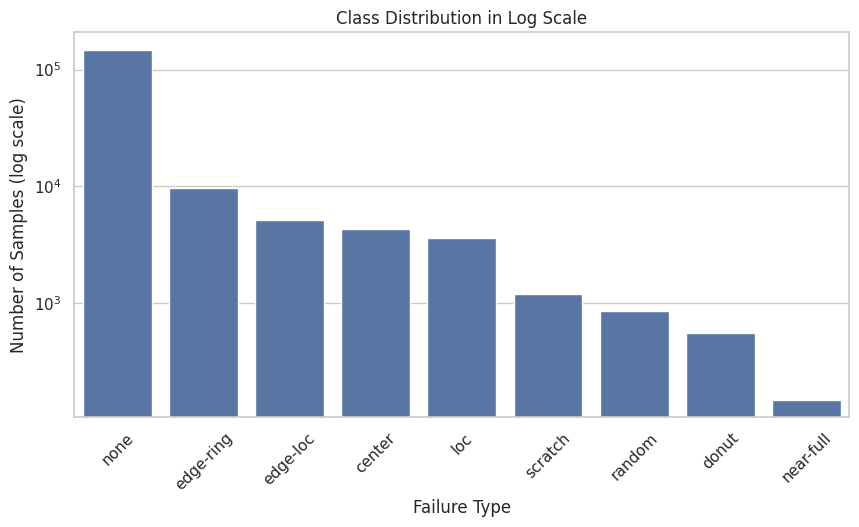

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Class Distribution in Log Scale")
plt.xlabel("Failure Type")
plt.ylabel("Number of Samples (log scale)")
plt.savefig(
    f"{EDA_OUTPUT_DIR}/class_distribution_in_log_scale.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Nhận xét:**  
Biểu đồ theo thang logarit giúp quan sát rõ hơn các lớp có số lượng mẫu nhỏ. Kết quả tiếp tục xác nhận rằng các lớp `near-full`, `donut`, `random` và `scratch` là các lớp thiểu số đáng chú ý.

Điều này cho thấy nếu chỉ dựa vào accuracy, mô hình có thể đạt kết quả cao nhưng vẫn phân loại kém các lớp lỗi hiếm. Do đó, trong giai đoạn đánh giá, cần phân tích kết quả theo từng lớp thay vì chỉ dùng chỉ số tổng quát.

## II.11. Thống kê kích thước wafer map gốc

**Mục đích:**  
Cell này kiểm tra kích thước không gian của các wafer map trong tập dữ liệu có nhãn nhằm xác định mức độ đa dạng về kích thước đầu vào.

**Thực hiện:**  
Mỗi wafer map được chuyển thành mảng `numpy`, sau đó lấy kích thước bằng `.shape`. Số lượng từng kích thước được thống kê bằng `value_counts()`.

In [14]:
def get_map_shape(x):
    arr = np.array(x)
    return arr.shape

labeled_df["map_shape"] = labeled_df["waferMap"].apply(get_map_shape)

shape_counts = labeled_df["map_shape"].value_counts()

print("Number of unique wafer map shapes:", len(shape_counts))
shape_counts.head(20).to_csv(f"{EDA_OUTPUT_DIR}/shape_counts_top20.csv")
shape_counts.head(20)

Number of unique wafer map shapes: 346


map_shape
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
(35, 31)     4331
(25, 26)     4174
(41, 38)     4152
(33, 37)     3729
(29, 27)     2872
(45, 42)     2648
(43, 44)     2578
(41, 40)     2572
(41, 45)     2313
(38, 36)     2127
Name: count, dtype: int64

**Nhận xét:**  
Kết quả cho thấy tập dữ liệu có **346 kích thước wafer map khác nhau**. Một số kích thước phổ biến gồm `(25, 27)`, `(26, 26)`, `(30, 34)`, `(29, 26)` và `(27, 25)`.

Sự đa dạng về kích thước này cho thấy không thể đưa trực tiếp wafer map gốc vào CNN nếu chưa chuẩn hóa. Đây là cơ sở để thực hiện bước resize toàn bộ wafer map về cùng kích thước, dự kiến là `26 x 26`, trước khi chuyển sang biểu diễn `26 x 26 x 3`.

## II.12. Phân bố dieSize

**Mục đích:**  
Cell này phân tích phân bố của biến `dieSize`, đại diện cho số lượng die hoặc kích thước liên quan đến wafer map.

**Thực hiện:**  
Sử dụng histogram để trực quan hóa phân bố `dieSize`, đồng thời dùng `.describe()` để thống kê các chỉ số như giá trị trung bình, độ lệch chuẩn, min, max và các phân vị.

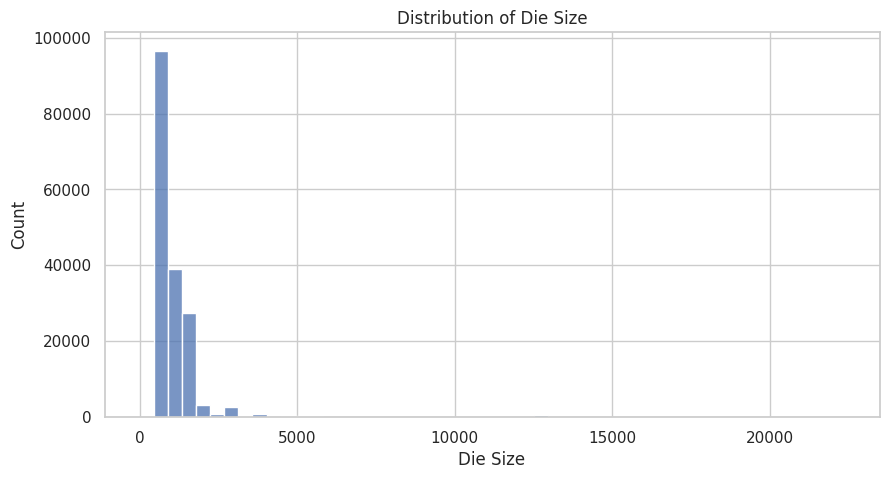

count    172950.000000
mean       1042.232374
std        1032.572449
min           3.000000
25%         533.000000
50%         776.000000
75%        1250.000000
max       22372.000000
Name: dieSize, dtype: float64

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(labeled_df["dieSize"], bins=50, kde=False)
plt.title("Distribution of Die Size")
plt.xlabel("Die Size")
plt.ylabel("Count")
plt.savefig(
    f"{EDA_OUTPUT_DIR}/dieSize_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

labeled_df["dieSize"].describe()

**Nhận xét:**  
Kết quả thống kê cho thấy `dieSize` có độ biến thiên lớn, với giá trị trung bình khoảng **1042.23**, độ lệch chuẩn khoảng **1032.57**, giá trị nhỏ nhất là **3** và giá trị lớn nhất lên đến **22,372**.

Điều này phản ánh sự đa dạng đáng kể về số lượng die hoặc cấu trúc wafer map trong bộ dữ liệu. Sự khác biệt này tiếp tục củng cố nhu cầu chuẩn hóa kích thước đầu vào trước khi huấn luyện mô hình học sâu.

## II.13. Trực quan một số wafer map theo từng lớp

**Mục đích:**  
Cell này hiển thị một số mẫu wafer map của từng lớp nhằm quan sát trực quan hình thái lỗi đặc trưng.

**Thực hiện:**  
Mỗi wafer map được hiển thị bằng bản đồ màu với ba trạng thái:
- `0`: background
- `1`: pass
- `2`: fail

Việc trực quan hóa theo từng lớp giúp kiểm tra dữ liệu có đúng đặc trưng hình thái mong đợi hay không.

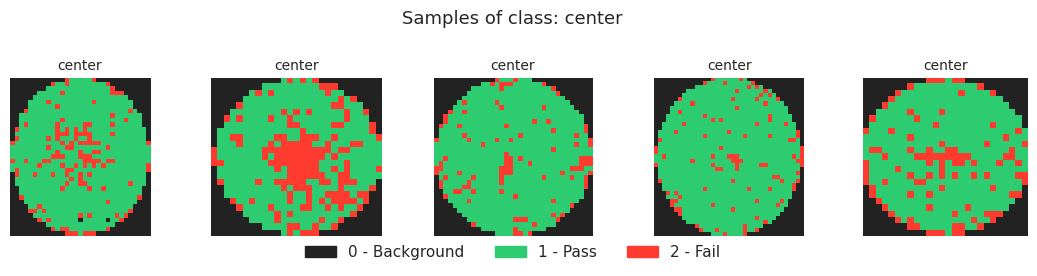

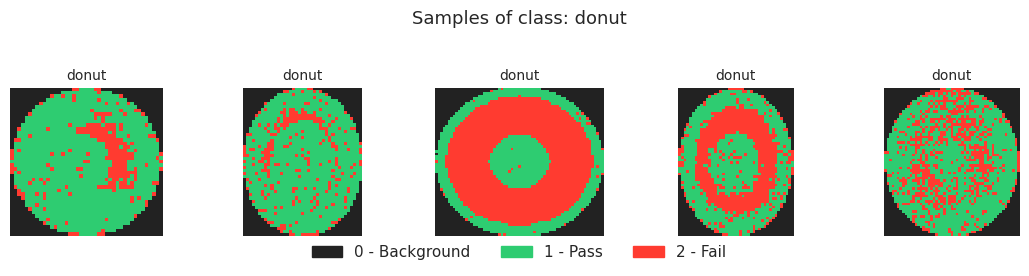

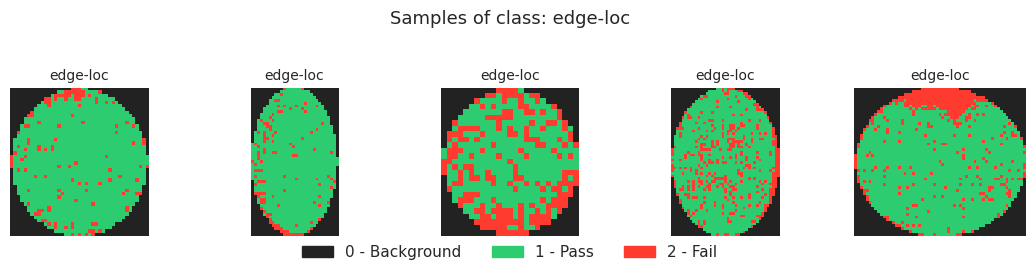

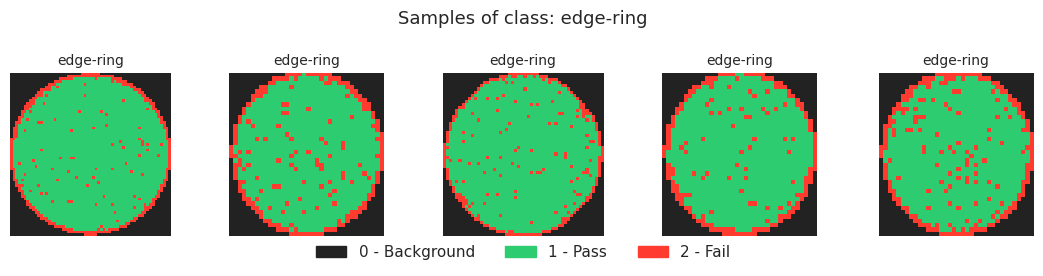

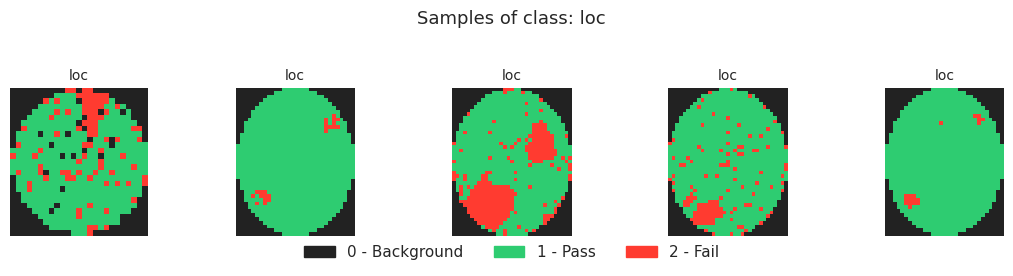

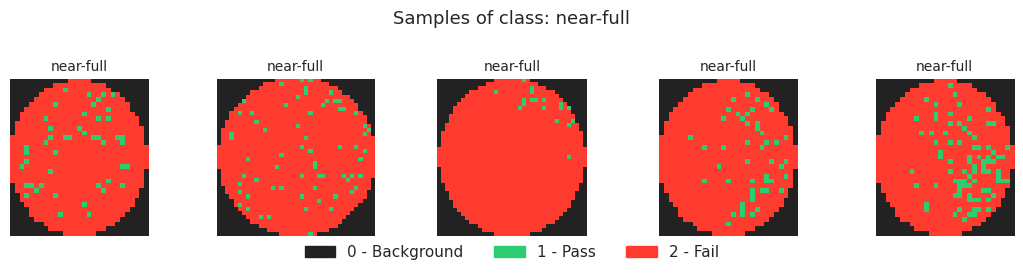

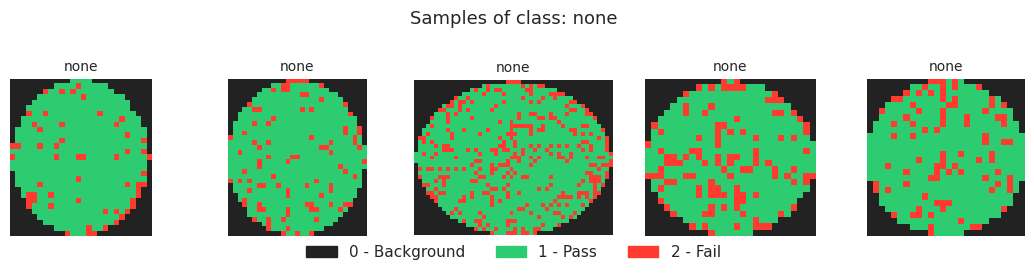

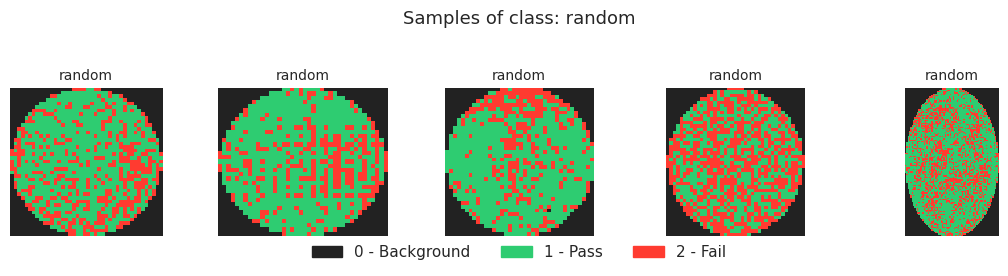

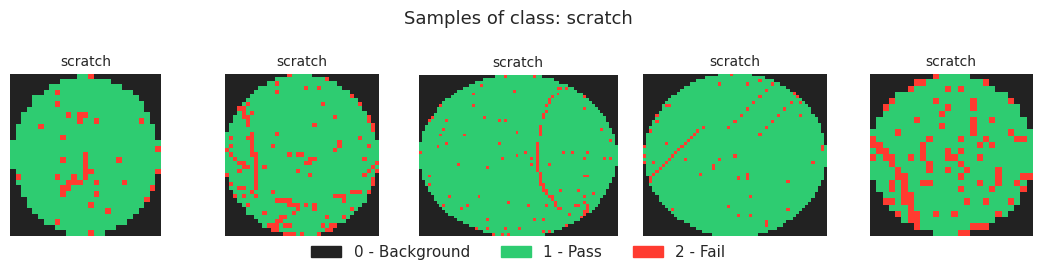

In [16]:
# Custom color map:
# 0 = background, 1 = pass, 2 = fail
wafer_cmap = ListedColormap([
    "#222222",  # background
    "#2ecc71",  # pass
    "#ff3b30"   # fail
])

wafer_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], wafer_cmap.N)

legend_patches = [
    mpatches.Patch(color="#222222", label="0 - Background"),
    mpatches.Patch(color="#2ecc71", label="1 - Pass"),
    mpatches.Patch(color="#ff3b30", label="2 - Fail")
]

def plot_samples_by_class_color(data, label_col="failure_label_clean", n_samples=5):
    labels = sorted(data[label_col].dropna().unique())

    for label in labels:
        subset = data[data[label_col] == label].sample(
            min(n_samples, len(data[data[label_col] == label])),
            random_state=42
        )

        fig, axes = plt.subplots(1, len(subset), figsize=(len(subset) * 2.2, 2.4))

        if len(subset) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, subset.iterrows()):
            wafer = np.array(row["waferMap"])

            ax.imshow(
                wafer,
                cmap=wafer_cmap,
                norm=wafer_norm,
                interpolation="nearest"
            )
            ax.axis("off")
            ax.set_title(label, fontsize=10)

        fig.legend(
            handles=legend_patches,
            loc="lower center",
            ncol=3,
            bbox_to_anchor=(0.5, -0.08),
            frameon=False
        )

        plt.suptitle(f"Samples of class: {label}", y=1.02, fontsize=13)
        plt.tight_layout()
        safe_label = str(label).replace("/", "_").replace(" ", "_")
        plt.savefig(
            f"{EDA_OUTPUT_DIR}/samples_of_class_{safe_label}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

plot_samples_by_class_color(labeled_df, n_samples=5)

**Nhận xét:**  
Các mẫu wafer map cho thấy mỗi lớp lỗi có đặc trưng không gian khác nhau. Ví dụ, `center` thường có lỗi tập trung gần vùng trung tâm, `edge-ring` thể hiện lỗi dọc theo vùng rìa, `edge-loc` xuất hiện cục bộ ở rìa, `scratch` có dạng vệt kéo dài, trong khi `random` có lỗi phân bố rải rác.

Quan sát này cho thấy bài toán không chỉ phụ thuộc vào tỷ lệ die lỗi, mà còn phụ thuộc mạnh vào hình thái và vị trí không gian của các die lỗi. Đây là cơ sở hợp lý để sử dụng CNN, đặc biệt là các khối trích xuất đặc trưng đa tỷ lệ và attention nhằm học tốt hơn cấu trúc không gian của wafer map.

## II.14. Tính tỷ lệ background, pass và fail trên từng wafer map

**Mục đích:**  
Cell này tính tỷ lệ ba trạng thái cơ bản trong mỗi wafer map gồm background, pass và fail. Đây là các đặc trưng thống kê đơn giản nhưng hữu ích để hiểu cấu trúc dữ liệu.

**Thực hiện:**  
Với mỗi wafer map, số lượng phần tử có giá trị `0`, `1`, `2` được đếm và chia cho tổng số phần tử của ma trận để tạo ra ba tỷ lệ: `background_ratio`, `pass_ratio` và `fail_ratio`.

In [17]:
def wafer_value_ratios(wafer):
    arr = np.array(wafer)
    total = arr.size

    bg_ratio = np.sum(arr == 0) / total
    pass_ratio = np.sum(arr == 1) / total
    fail_ratio = np.sum(arr == 2) / total

    return pd.Series({
        "background_ratio": bg_ratio,
        "pass_ratio": pass_ratio,
        "fail_ratio": fail_ratio
    })

ratio_df = labeled_df["waferMap"].apply(wafer_value_ratios)
labeled_df = pd.concat([labeled_df, ratio_df], axis=1)

labeled_df[["failure_label", "background_ratio", "pass_ratio", "fail_ratio"]].head()

,failure_label,background_ratio,pass_ratio,fail_ratio
0,none,0.220833,0.738426,0.040741
1,none,0.220833,0.739352,0.039815
2,none,0.220833,0.748611,0.030556
3,none,0.220833,0.731019,0.048148
4,none,0.220833,0.746296,0.032870


**Nhận xét:**  
Các tỷ lệ background, pass và fail giúp mô tả sơ bộ mức độ lỗi trong từng wafer map. Tuy nhiên, những tỷ lệ này chỉ phản ánh thông tin tổng quát về số lượng die lỗi, chưa mô tả được vị trí và hình thái phân bố lỗi.

Do đó, các đặc trưng thống kê này có thể hỗ trợ phân tích dữ liệu, nhưng chưa đủ để phân loại chính xác các dạng lỗi có hình thái phức tạp. Mô hình CNN vẫn cần thiết để học các đặc trưng không gian từ dữ liệu wafer map.

## II.15. So sánh tỷ lệ fail theo từng lớp

**Mục đích:**  
Cell này phân tích sự khác biệt về tỷ lệ die lỗi giữa các lớp bằng biểu đồ boxplot.

**Thực hiện:**  
Tỷ lệ `fail_ratio` được so sánh theo từng nhãn lỗi nhằm đánh giá xem các lớp có khác biệt đáng kể về mức độ lỗi hay không.

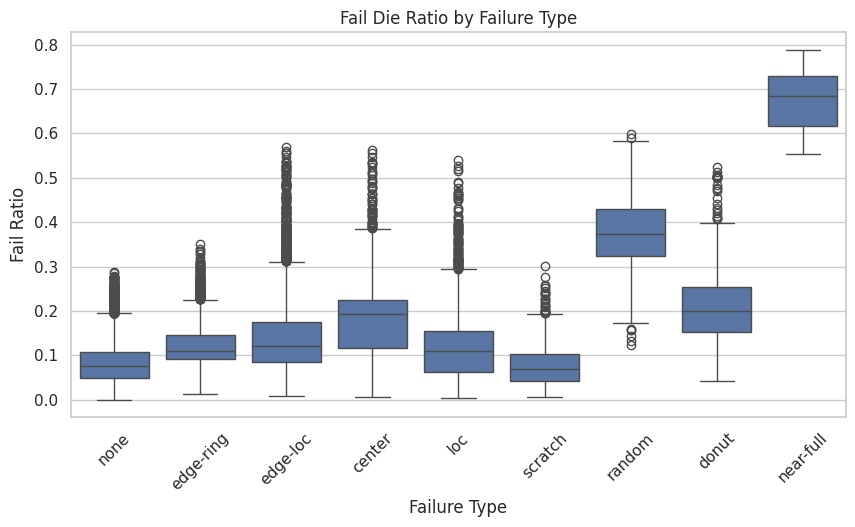

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=labeled_df,
    x="failure_label_clean",
    y="fail_ratio",
    order=class_counts.index
)
plt.xticks(rotation=45)
plt.title("Fail Die Ratio by Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Fail Ratio")
plt.savefig(
    f"{EDA_OUTPUT_DIR}/fail_ratio_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Nhận xét:**  
Biểu đồ boxplot cho thấy tỷ lệ die lỗi có sự khác biệt giữa các lớp. Một số lớp có tỷ lệ fail cao hơn, trong khi các lớp như `scratch`, `loc` hoặc `edge-loc` có thể không chỉ khác biệt ở số lượng die lỗi mà còn ở cách các die lỗi phân bố trong không gian.

Kết quả này cho thấy chỉ dùng `fail_ratio` là chưa đủ để phân biệt toàn bộ 9 lớp. Hai wafer map có tỷ lệ fail tương tự nhau vẫn có thể thuộc hai lớp khác nhau nếu hình thái lỗi khác nhau. Đây là một luận điểm quan trọng để giải thích vì sao cần sử dụng mô hình học sâu dựa trên ảnh thay vì chỉ dùng các đặc trưng thống kê thủ công.

## II.16. Bảng tổng hợp các đặc trưng thống kê theo lớp

**Mục đích:**  
Cell này tổng hợp các chỉ số thống kê chính theo từng lớp, bao gồm số lượng mẫu, kích thước die trung bình, tỷ lệ background trung bình, tỷ lệ pass trung bình và tỷ lệ fail trung bình.

**Thực hiện:**  
Dữ liệu được nhóm theo `failure_label_clean`, sau đó tính các giá trị trung bình và số lượng mẫu cho từng lớp.

In [19]:
eda_summary = labeled_df.groupby("failure_label_clean").agg(
    count=("failure_label_clean", "count"),
    avg_die_size=("dieSize", "mean"),
    avg_background_ratio=("background_ratio", "mean"),
    avg_pass_ratio=("pass_ratio", "mean"),
    avg_fail_ratio=("fail_ratio", "mean")
).sort_values("count", ascending=False)

eda_summary = eda_summary.round(4)
eda_summary.to_csv(f"{EDA_OUTPUT_DIR}/eda_summary.csv")
eda_summary

,count,avg_die_size,avg_background_ratio,avg_pass_ratio,avg_fail_ratio
failure_label_clean,,,,,
none,147431,921.3790,0.2287,0.6898,0.0815
edge-ring,9680,2601.0812,0.2190,0.6628,0.1182
edge-loc,5189,1171.1507,0.2268,0.6319,0.1413
center,4294,928.6176,0.2315,0.5903,0.1783
loc,3593,1351.0214,0.2241,0.6598,0.1162
scratch,1193,2010.4300,0.2232,0.6988,0.0780
random,866,1191.2760,0.2199,0.4049,0.3751
donut,555,1377.5009,0.2232,0.5616,0.2151
near-full,149,821.4564,0.2266,0.0952,0.6783


**Nhận xét:**  
Bảng tổng hợp cho thấy các lớp không chỉ khác nhau về số lượng mẫu mà còn khác nhau về các đặc trưng thống kê như `dieSize` và `fail_ratio`. Ví dụ, lớp `none` có số lượng mẫu vượt trội, trong khi các lớp lỗi hiếm có số lượng mẫu rất thấp.

Bảng này cung cấp cơ sở định lượng cho việc mô tả dữ liệu trong báo cáo đề án. Đồng thời, kết quả cũng cho thấy cần kết hợp cả phân tích thống kê và mô hình học sâu để xử lý bài toán phân loại wafer map một cách hiệu quả.

## II.17. Nhận xét tổng quan sau khi khám phá dữ liệu

**Qua quá trình khám phá dữ liệu WM-811K, có thể rút ra một số nhận xét chính như sau:**

- Bộ dữ liệu WM-811K có quy mô rất lớn với **811,457 mẫu**, tuy nhiên chỉ có **172,950 mẫu có nhãn** được sử dụng cho bài toán phân loại có giám sát. Phần còn lại gồm **638,507 mẫu không có nhãn** sẽ không được sử dụng trong phạm vi phân loại 9 lớp của đề tài.

- Trong tập dữ liệu có nhãn, lớp `none` chiếm ưu thế tuyệt đối với **147,431 mẫu**, tương đương khoảng **85.24%**. Trong khi đó, các lớp lỗi hiếm như `near-full`, `donut`, `random` và `scratch` có số lượng mẫu rất thấp.

- Tỷ lệ mất cân bằng giữa lớp lớn nhất và lớp nhỏ nhất đạt khoảng **989.47 lần**, cho thấy đây là một bài toán mất cân bằng lớp nghiêm trọng. Điều này có thể khiến mô hình thiên lệch về lớp đa số nếu không có chiến lược xử lý phù hợp.

- Wafer map trong dữ liệu gốc có **346 kích thước khác nhau**, vì vậy cần chuẩn hóa kích thước đầu vào trước khi đưa vào mô hình CNN. Trong đề tài này, hướng xử lý dự kiến là resize wafer map về `26 x 26`.

- Các wafer map có ba trạng thái cơ bản gồm background, pass và fail. Việc chuyển dữ liệu sang biểu diễn one-hot ba kênh `background/pass/fail` là phù hợp hơn so với việc sử dụng trực tiếp giá trị rời rạc `0/1/2`.

- Quan sát trực quan cho thấy các lớp lỗi khác nhau không chỉ ở tỷ lệ die lỗi mà còn ở hình thái và vị trí không gian của lỗi. Do đó, mô hình cần có khả năng học đặc trưng không gian thay vì chỉ dựa vào thống kê tổng quát.

Từ các nhận xét trên, các bước tiếp theo của đề tài sẽ tập trung vào:
1. Tiền xử lý dữ liệu: resize wafer map về cùng kích thước và chuyển sang biểu diễn one-hot 3 kênh.
2. Chia dữ liệu theo chiến lược stratified split để giữ nguyên phân bố lớp trong train, validation và test.
3. Xử lý mất cân bằng dữ liệu bằng class weighting và data augmentation.
4. Xây dựng mô hình CNN nhẹ có khả năng học đặc trưng đa tỷ lệ và tích hợp cơ chế attention để cải thiện khả năng nhận diện các lớp lỗi hiếm.

# III. PREPROCESSING - TIỀN XỬ LÝ DỮ LIỆU
Sau giai đoạn EDA, bộ dữ liệu đã được xác định gồm **172,950 mẫu có nhãn** dùng cho bài toán phân loại 9 lớp. Giai đoạn Preprocessing nhằm chuyển dữ liệu wafer map thô thành định dạng thống nhất, phù hợp để đưa vào mô hình học sâu.

Các bước chính gồm:

1. Cấu hình tham số và ánh xạ nhãn.
2. Kiểm tra tính hợp lệ của nhãn.
3. Tạo DataFrame trung gian.
4. Resize wafer map và chuyển sang one-hot 3 kênh.
5. Tiền xử lý toàn bộ dữ liệu.
6. Kiểm tra trực quan dữ liệu sau tiền xử lý.
7. Chia train/validation/test theo stratified split.
8. Kiểm tra phân bố lớp sau chia tập.
9. Trực quan hóa phân bố lớp sau chia tập.
10. Lưu output sau tiền xử lý.

Lưu ý quan trọng: ở giai đoạn này **chưa thực hiện data augmentation**. Validation set và test set cần được giữ nguyên để đảm bảo việc đánh giá mô hình khách quan.

## III.1. Cấu hình tham số và ánh xạ nhãn

**Mục đích:**  
Thiết lập các tham số chính cho quá trình tiền xử lý, bao gồm kích thước ảnh đầu vào, số kênh, random seed và danh sách 9 lớp cần phân loại.

**Thực hiện:**  
Wafer map sẽ được chuẩn hóa về kích thước `26 x 26`. Nhãn dạng chữ được ánh xạ sang nhãn số từ `0` đến `8`.

**Kết quả kỳ vọng:**  
Tạo được bảng `label_mapping_df` thể hiện ánh xạ giữa tên lớp và mã số lớp.

In [20]:
TARGET_HEIGHT = 26
TARGET_WIDTH = 26
N_CHANNELS = 3
RANDOM_STATE = 42

PREPROCESS_OUTPUT_DIR = "/kaggle/working/preprocessing_outputs"
os.makedirs(PREPROCESS_OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = [
    "center",
    "donut",
    "scratch",
    "near-full",
    "edge-ring",
    "edge-loc",
    "loc",
    "random",
    "none"
]

label_to_id = {label: idx for idx, label in enumerate(CLASS_NAMES)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

label_mapping_df = pd.DataFrame({
    "label": CLASS_NAMES,
    "label_id": [label_to_id[label] for label in CLASS_NAMES]
})

label_mapping_df

,label,label_id
0,center,0
1,donut,1
2,scratch,2
3,near-full,3
4,edge-ring,4
5,edge-loc,5
6,loc,6
7,random,7
8,none,8


**Nhận xét:**  
Bộ nhãn được cố định gồm 9 lớp theo đúng phạm vi bài toán phân loại wafer map. Việc cố định thứ tự nhãn giúp đảm bảo tính nhất quán trong toàn bộ pipeline, đặc biệt khi huấn luyện mô hình, đánh giá confusion matrix và xuất kết quả báo cáo.

## III.2. Kiểm tra tính hợp lệ của nhãn

**Mục đích:**  
Kiểm tra xem toàn bộ nhãn trong `labeled_df` có thuộc đúng 9 lớp đã định nghĩa hay không.

**Thực hiện:**  
Danh sách nhãn duy nhất trong `labeled_df` được so sánh với `CLASS_NAMES`.

**Kết quả kỳ vọng:**  
`invalid_labels` và `missing_labels` đều là tập rỗng.

In [21]:
unique_labels = sorted(labeled_df["failure_label_clean"].unique())

print("Unique labels in labeled_df:")
print(unique_labels)

invalid_labels = set(unique_labels) - set(CLASS_NAMES)
missing_labels = set(CLASS_NAMES) - set(unique_labels)

print("\nInvalid labels:", invalid_labels)
print("Missing labels:", missing_labels)

Unique labels in labeled_df:
['center', 'donut', 'edge-loc', 'edge-ring', 'loc', 'near-full', 'none', 'random', 'scratch']

Invalid labels: set()
Missing labels: set()


**Nhận xét kết quả:**  
Nếu không có nhãn sai hoặc nhãn thiếu, dữ liệu đã hợp lệ để tiếp tục mã hóa nhãn và tiền xử lý.

**Ý nghĩa cho pipeline:**  
Bước này giúp tránh lỗi trong quá trình huấn luyện do nhãn nằm ngoài phạm vi 9 lớp.

## III.3. Tạo DataFrame trung gian cho tiền xử lý

**Mục đích:**  
Tạo DataFrame chỉ chứa các thông tin cần thiết cho giai đoạn tiền xử lý.

**Thực hiện:**  
Giữ lại `waferMap`, `failure_label_clean`, sau đó tạo thêm `label_id`.

**Kết quả kỳ vọng:**  
Tạo được `pre_df` gồm wafer map gốc, nhãn chữ và nhãn số.

In [22]:
# Keep only needed columns for preprocessing

pre_df = labeled_df[["waferMap", "failure_label_clean"]].copy()
pre_df["label_id"] = pre_df["failure_label_clean"].map(label_to_id)

print("Preprocessing dataframe shape:", pre_df.shape)
display(pre_df.head())

Preprocessing dataframe shape: (172950, 3)


,waferMap,failure_label_clean,label_id
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",none,8
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",none,8
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",none,8
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",none,8
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",none,8


**Nhận xét kết quả:**  
`pre_df` đã được tạo thành công và chỉ chứa các cột cần thiết cho pipeline tiền xử lý.

**Ý nghĩa cho pipeline:**  
Dữ liệu trung gian này giúp các bước resize, one-hot encoding và chia tập rõ ràng hơn.

## III.4. Xây dựng hàm resize và one-hot encoding

**Mục đích:**  
Xây dựng hàm chuyển wafer map thô thành dữ liệu đầu vào chuẩn cho CNN.

**Thực hiện:**  
Wafer map được resize về `26 x 26` bằng nearest-neighbor để giữ nguyên các giá trị rời rạc `0/1/2`. Sau đó, dữ liệu được chuyển sang one-hot 3 kênh: background, pass và fail.

**Kết quả kỳ vọng:**  
Một wafer map sau xử lý có kích thước `26 x 26 x 3`.

In [23]:
def resize_nearest_2d(arr, target_h=26, target_w=26):
    arr = np.asarray(arr)

    src_h, src_w = arr.shape

    row_idx = np.linspace(0, src_h - 1, target_h).round().astype(int)
    col_idx = np.linspace(0, src_w - 1, target_w).round().astype(int)

    resized = arr[np.ix_(row_idx, col_idx)]
    return resized.astype(np.uint8)


def wafer_to_onehot_3ch(wafer, target_h=26, target_w=26):
    resized = resize_nearest_2d(wafer, target_h, target_w)

    onehot = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    onehot[:, :, 0] = (resized == 0)
    onehot[:, :, 1] = (resized == 1)
    onehot[:, :, 2] = (resized == 2)

    return onehot


sample_wafer = pre_df.iloc[0]["waferMap"]
sample_processed = wafer_to_onehot_3ch(sample_wafer, TARGET_HEIGHT, TARGET_WIDTH)

print("Original shape:", np.asarray(sample_wafer).shape)
print("Processed shape:", sample_processed.shape)
print("Unique values in processed one-hot:", np.unique(sample_processed))
print("One-hot sum per pixel unique values:", np.unique(sample_processed.sum(axis=-1)))

Original shape: (45, 48)
Processed shape: (26, 26, 3)
Unique values in processed one-hot: [0 1]
One-hot sum per pixel unique values: [1]


**Nhận xét kết quả:**  
Một wafer map mẫu đã được chuyển thành kích thước `26 x 26 x 3`. Giá trị trong one-hot chỉ gồm `0` và `1`, đồng thời tổng theo chiều kênh tại mỗi pixel bằng `1`.

**Ý nghĩa cho pipeline:**  
Hàm tiền xử lý hoạt động đúng và có thể áp dụng cho toàn bộ tập dữ liệu.

## III.5. Tiền xử lý toàn bộ wafer map

**Mục đích:**  
Áp dụng resize và one-hot encoding cho toàn bộ tập dữ liệu có nhãn.

**Thực hiện:**  
Mỗi wafer map trong `pre_df` được xử lý bằng `wafer_to_onehot_3ch()`. Nhãn số được lấy từ cột `label_id`.

**Kết quả kỳ vọng:**  
`X` có dạng `(172950, 26, 26, 3)` và `y` có dạng `(172950,)`.

In [24]:
# Process all wafer maps

X = np.stack([
    wafer_to_onehot_3ch(wafer, TARGET_HEIGHT, TARGET_WIDTH)
    for wafer in pre_df["waferMap"].values
])

y = pre_df["label_id"].values.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print("X min:", X.min(), "X max:", X.max())
print("Labels:", np.unique(y))

X shape: (172950, 26, 26, 3)
y shape: (172950,)
X dtype: uint8
y dtype: int64
X min: 0 X max: 1
Labels: [0 1 2 3 4 5 6 7 8]


**Nhận xét kết quả:**  
Dữ liệu đầu vào đã được chuẩn hóa thành mảng `X` với kích thước thống nhất `26 x 26 x 3`. Mảng `y` chứa nhãn số tương ứng cho từng wafer map.

**Ý nghĩa cho pipeline:**  
Dữ liệu đã sẵn sàng để kiểm tra trực quan và chia thành train, validation, test set.

## III.6. Kiểm tra trực quan dữ liệu sau tiền xử lý

**Mục đích:**  
So sánh wafer map gốc và wafer map sau tiền xử lý để kiểm tra chất lượng resize.

**Thực hiện:**  
Một số mẫu wafer được hiển thị song song: bên trái là dữ liệu gốc, bên phải là dữ liệu sau resize về `26 x 26`.

**Kết quả kỳ vọng:**  
Wafer map sau xử lý vẫn giữ được hình thái tổng quát của mẫu gốc.

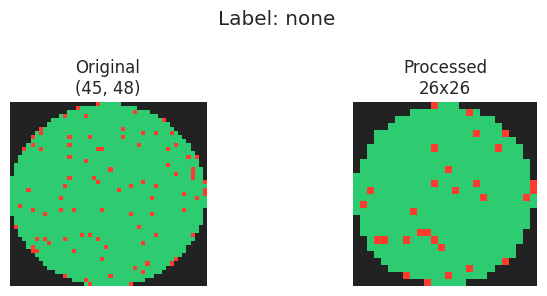

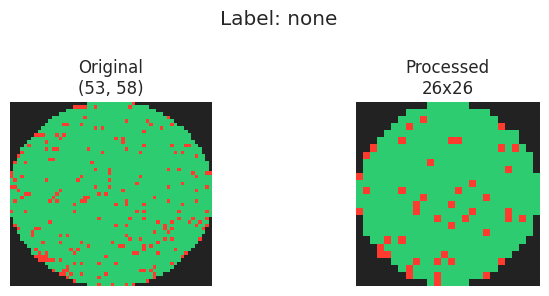

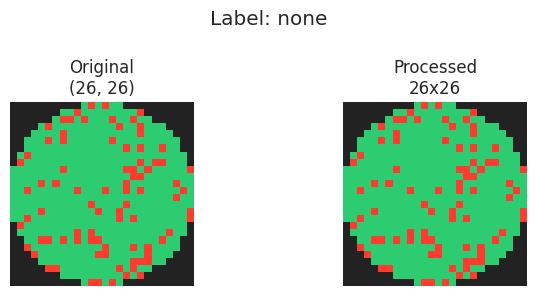

In [25]:
# Visual check after preprocessing

def show_original_and_processed(index):
    original = np.asarray(pre_df.iloc[index]["waferMap"])
    processed = X[index]
    label = pre_df.iloc[index]["failure_label_clean"]

    processed_label_map = np.argmax(processed, axis=-1)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    axes[0].imshow(
        original,
        cmap=wafer_cmap,
        norm=wafer_norm,
        interpolation="nearest"
    )
    axes[0].set_title(f"Original\n{original.shape}")
    axes[0].axis("off")

    axes[1].imshow(
        processed_label_map,
        cmap=wafer_cmap,
        norm=wafer_norm,
        interpolation="nearest"
    )
    axes[1].set_title("Processed\n26x26")
    axes[1].axis("off")

    plt.suptitle(f"Label: {label}")
    plt.tight_layout()
    plt.show()

show_original_and_processed(0)
show_original_and_processed(100)
show_original_and_processed(1000)

**Nhận xét kết quả:**  
Kết quả trực quan giúp xác nhận wafer map sau resize vẫn giữ được cấu trúc không gian cơ bản.

**Ý nghĩa cho pipeline:**  
Sau khi dữ liệu sau xử lý được kiểm tra trực quan, có thể tiếp tục chia tập dữ liệu cho huấn luyện và đánh giá.

## III.7. Chia dữ liệu thành train, validation và test set

**Mục đích:**  
Chia dữ liệu thành ba tập train, validation và test theo tỷ lệ `70% / 15% / 15%`.

**Thực hiện:**  
Sử dụng `train_test_split` với `stratify` để giữ phân bố lớp ổn định giữa các tập.

**Kết quả kỳ vọng:**  
Tạo được `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [26]:
# First split: train 70%, temp 30%

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (121065, 26, 26, 3) (121065,)
Validation: (25942, 26, 26, 3) (25942,)
Test: (25943, 26, 26, 3) (25943,)


**Nhận xét kết quả:**  
Dữ liệu đã được chia thành ba tập với tỷ lệ xấp xỉ `70% / 15% / 15%`.

**Ý nghĩa cho pipeline:**  
Train set sẽ được dùng để huấn luyện mô hình. Validation set dùng để theo dõi quá trình huấn luyện và chọn mô hình. Test set chỉ dùng cho đánh giá cuối cùng.

## III.8. Kiểm tra phân bố lớp sau khi chia tập

**Mục đích:**  
Kiểm tra số lượng và tỷ lệ từng lớp trong train, validation và test set.

**Thực hiện:**  
Tạo bảng `split_summary` thống kê số lượng mẫu và tỷ lệ phần trăm của từng lớp trong từng tập.

**Kết quả kỳ vọng:**  
Phân bố lớp trong ba tập gần tương đương với phân bố ban đầu.

In [28]:
def split_distribution_table(y_array, split_name):
    counts = pd.Series(y_array).value_counts().sort_index()

    table = pd.DataFrame({
        "label_id": counts.index,
        "label": [id_to_label[i] for i in counts.index],
        split_name: counts.values
    })

    table[f"{split_name}_percentage"] = (
        table[split_name] / table[split_name].sum() * 100
    ).round(4)

    return table


train_dist = split_distribution_table(y_train, "train_count")
val_dist = split_distribution_table(y_val, "val_count")
test_dist = split_distribution_table(y_test, "test_count")

split_summary = train_dist.merge(val_dist, on=["label_id", "label"])
split_summary = split_summary.merge(test_dist, on=["label_id", "label"])

split_summary

,label_id,label,train_count,train_count_percentage,val_count,val_count_percentage,test_count,test_count_percentage
0,0,center,3006,2.4830,644,2.4825,644,2.4824
1,1,donut,389,0.3213,83,0.3199,83,0.3199
2,2,scratch,835,0.6897,179,0.6900,179,0.6900
3,3,near-full,104,0.0859,23,0.0887,22,0.0848
4,4,edge-ring,6776,5.5970,1452,5.5971,1452,5.5969
5,5,edge-loc,3632,3.0000,778,2.9990,779,3.0027
6,6,loc,2515,2.0774,539,2.0777,539,2.0776
7,7,random,606,0.5006,130,0.5011,130,0.5011
8,8,none,103202,85.2451,22114,85.2440,22115,85.2446


**Nhận xét kết quả:**  
Bảng `split_summary` cho phép kiểm tra các lớp có được phân bố hợp lý trong train, validation và test set hay không.

**Ý nghĩa cho pipeline:**  
Vì WM-811K mất cân bằng nghiêm trọng, việc đảm bảo các lớp thiểu số vẫn xuất hiện trong validation và test set là rất quan trọng.

## III.9. Trực quan hóa phân bố lớp trong các tập dữ liệu

**Mục đích:**  
Trực quan hóa số lượng mẫu của từng lớp trong train, validation và test set.

**Thực hiện:**  
Vẽ biểu đồ countplot theo từng lớp và từng tập dữ liệu. Trục tung sử dụng thang logarit để dễ quan sát các lớp thiểu số.

**Kết quả kỳ vọng:**  
Biểu đồ thể hiện rõ phân bố lớp trong train, validation và test set.

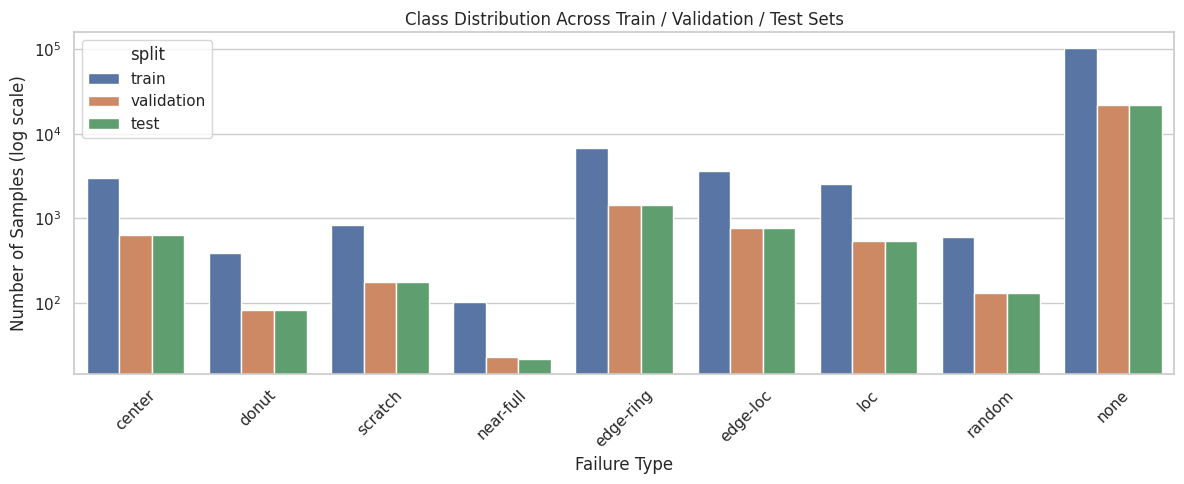

In [29]:
train_plot_df = pd.DataFrame({
    "label": [id_to_label[i] for i in y_train],
    "split": ["train"] * len(y_train)
})

val_plot_df = pd.DataFrame({
    "label": [id_to_label[i] for i in y_val],
    "split": ["validation"] * len(y_val)
})

test_plot_df = pd.DataFrame({
    "label": [id_to_label[i] for i in y_test],
    "split": ["test"] * len(y_test)
})

combined_split_df = pd.concat(
    [train_plot_df, val_plot_df, test_plot_df],
    ignore_index=True
)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=combined_split_df,
    x="label",
    hue="split",
    order=CLASS_NAMES
)
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Class Distribution Across Train / Validation / Test Sets")
plt.xlabel("Failure Type")
plt.ylabel("Number of Samples (log scale)")
plt.tight_layout()
plt.savefig(
    f"{PREPROCESS_OUTPUT_DIR}/split_class_distribution_log.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Nhận xét kết quả:**  
Biểu đồ giúp xác nhận trực quan rằng phân bố lớp trong train, validation và test set có xu hướng tương tự nhau.

**Ý nghĩa cho pipeline:**  
Đây là bằng chứng trực quan cho báo cáo rằng quá trình chia dữ liệu được thực hiện có kiểm soát bằng stratified split.

## III.10. Lưu output sau tiền xử lý

**Mục đích:**  
Lưu lại các kết quả quan trọng sau giai đoạn tiền xử lý để sử dụng cho các bước tiếp theo.

**Thực hiện:**  
Lưu bảng ánh xạ nhãn, bảng phân bố lớp sau chia tập và dữ liệu đã tiền xử lý dạng `.npz`.

**Kết quả kỳ vọng:**  
Các file output được lưu trong thư mục `/kaggle/working/preprocessing_outputs`.

In [30]:
label_mapping_df.to_csv(
    f"{PREPROCESS_OUTPUT_DIR}/label_mapping.csv",
    index=False
)

split_summary.to_csv(
    f"{PREPROCESS_OUTPUT_DIR}/split_summary.csv",
    index=False
)

np.savez_compressed(
    f"{PREPROCESS_OUTPUT_DIR}/preprocessed_wm811k_26x26.npz",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    class_names=np.array(CLASS_NAMES)
)

print("Saved preprocessing outputs to:", PREPROCESS_OUTPUT_DIR)

Saved preprocessing outputs to: /kaggle/working/preprocessing_outputs


**Nhận xét kết quả:**  
Các output của giai đoạn tiền xử lý đã được lưu thành công. File `.npz` chứa dữ liệu train, validation và test sau khi resize, one-hot encoding và chia tập.

**Ý nghĩa cho pipeline:**  
Dữ liệu đã sẵn sàng cho giai đoạn xây dựng mô hình baseline. Các kỹ thuật xử lý mất cân bằng hoặc augmentation sẽ chỉ được áp dụng trên train set ở các bước tiếp theo.

## Tổng kết phần Preprocessing

Sau giai đoạn Preprocessing, dữ liệu wafer map đã được chuyển từ dạng thô sang định dạng phù hợp cho mô hình học sâu.

Các kết quả chính gồm:

- Toàn bộ dữ liệu sử dụng là các mẫu có nhãn từ phần EDA.
- Wafer map được resize về kích thước thống nhất `26 x 26`.
- Dữ liệu được chuyển sang biểu diễn one-hot 3 kênh tương ứng với `background`, `pass` và `fail`.
- Nhãn 9 lớp được mã hóa thành dạng số từ `0` đến `8`.
- Dữ liệu được chia thành train, validation và test theo tỷ lệ `70% / 15% / 15%` bằng stratified split.
- Các output quan trọng đã được lưu lại để phục vụ huấn luyện mô hình và báo cáo.

Giai đoạn tiếp theo sẽ xây dựng mô hình baseline CNN trên dữ liệu đã tiền xử lý. Baseline này đóng vai trò mốc so sánh ban đầu trước khi áp dụng các kỹ thuật xử lý mất cân bằng, augmentation và mô hình đề xuất.

# IV. Baseline Models (No augmentation)

Giai đoạn này xây dựng các mô hình baseline trên dữ liệu đã tiền xử lý. Mục tiêu là tạo mốc so sánh ban đầu trước khi áp dụng class weight, data augmentation, CAE augmentation và mô hình đề xuất.

Các mô hình baseline gồm hai nhóm:

1. Mô hình học máy truyền thống:
   - SGDClassifier
   - Linear SVM
   - Decision Tree
   - Random Forest

2. Mô hình học sâu:
   - TinyCNN
   - LeNetCNN
   - DeeperCNN_BN
   - MobileNetV2
   - ShuffleNetV2-style
   - EfficientNetB0
   - LightweightGAPCNN

Các mô hình được đánh giá theo:
- Accuracy
- Precision
- Recall
- F1-score
- Macro-F1
- Params
- FLOPs
- Training time
- Inference time

Ở giai đoạn baseline này, toàn bộ mô hình được huấn luyện trên dữ liệu gốc đã preprocessing, chưa sử dụng augmentation và chưa sử dụng class weight.

## IV.1. Cấu hình chung

In [49]:
import time
import json
import warnings
import logging
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier   

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

BASELINE_OUTPUT_DIR = "/kaggle/working/baseline_outputs"
os.makedirs(BASELINE_OUTPUT_DIR, exist_ok=True)

BASELINE_MODEL_DIR = f"{BASELINE_OUTPUT_DIR}/models"
os.makedirs(BASELINE_MODEL_DIR, exist_ok=True)

experiment_results = []

print("TensorFlow version:", tf.__version__)
print("Baseline output directory:", BASELINE_OUTPUT_DIR)

TensorFlow version: 2.19.0
Baseline output directory: /kaggle/working/baseline_outputs


## IV.2. Hàm đánh giá và ghi nhận kết quả

In [33]:
def evaluate_classification(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def save_classification_outputs(model_name, y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(f"{BASELINE_OUTPUT_DIR}/{model_name}_classification_report.csv")

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_df.to_csv(f"{BASELINE_OUTPUT_DIR}/{model_name}_confusion_matrix.csv")

    return report_df, cm_df


def add_experiment_result(
    model_name,
    model_group,
    metrics,
    params=None,
    flops=None,
    training_time=None,
    inference_time=None,
    notes=""
):
    experiment_results.append({
        "model_name": model_name,
        "model_group": model_group,
        "data_setting": "original_preprocessed_no_aug_no_class_weight",
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "precision_weighted": metrics["precision_weighted"],
        "recall_weighted": metrics["recall_weighted"],
        "f1_weighted": metrics["f1_weighted"],
        "params": params,
        "flops": flops,
        "training_time_sec": training_time,
        "inference_time_sec": inference_time,
        "inference_time_per_sample_ms": (
            inference_time / len(y_test) * 1000 if inference_time is not None else None
        ),
        "notes": notes
    })


def get_experiment_results_df():
    return pd.DataFrame(experiment_results)

display(HTML("<span style = 'color: blue; font-weight:bold;'> Hàm đánh giá và ghi nhận kết quả đã sẵn sàng.</span>"))

## IV.3. Chuẩn bị dữ liệu cho mô hình học máy

In [34]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("X_test_flat:", X_test_flat.shape)

X_train_flat: (121065, 2028)
X_val_flat: (25942, 2028)
X_test_flat: (25943, 2028)


## IV.4. Khai báo 4 mô hình ML 

In [53]:
RANDOM_STATE = 42
ml_models = {
    "SGDClassifier": SGDClassifier(
        loss="log_loss",           
        max_iter=2000,            
        tol=1e-4,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        alpha=0.0001,             
        learning_rate='adaptive',  
        eta0=0.01,
        power_t=0.5
    ),
    "LinearSVM": LinearSVC(
        C=1.0,
        dual=False,                
        max_iter=5000,           
        tol=1e-4,
        random_state=RANDOM_STATE,
        class_weight='balanced'    
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=800,              # tương đương n_estimators
        learning_rate=0.1,
        max_depth=12,
        min_samples_leaf=20,
        l2_regularization=1.0,
        class_weight='balanced',   # rất quan trọng cho WM-811K
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=15,              
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    "XGBoost": XGBClassifier(
         n_estimators=300,
         max_depth=8,
         learning_rate=0.1,
         subsample=0.8,
         colsample_bytree=0.8,
         eval_metric='mlogloss',
         random_state=RANDOM_STATE,
         tree_method='hist'   # nhanh hơn
     ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,          
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        class_weight='balanced',   
        bootstrap=True,
        oob_score=True            
    )
}

print("Available ML models:")
for name in ml_models.keys():
    print("-", name)

Available ML models:
- SGDClassifier
- LinearSVM
- HistGradientBoosting
- DecisionTree
- XGBoost
- RandomForest


## IV.5. Định nghĩa hàm chạy mô hình ML

In [36]:
def run_ml_baseline(model_name):
    print("=" * 80)
    print("Training ML baseline:", model_name)

    model = ml_models[model_name]

    start_train = time.time()
    model.fit(X_train_flat, y_train)
    training_time = time.time() - start_train

    start_infer = time.time()
    y_pred = model.predict(X_test_flat)
    inference_time = time.time() - start_infer

    metrics = evaluate_classification(y_test, y_pred)
    report_df, cm_df = save_classification_outputs(model_name, y_test, y_pred)

    add_experiment_result(
        model_name=model_name,
        model_group="Traditional ML",
        metrics=metrics,
        params=None,
        flops=None,
        training_time=training_time,
        inference_time=inference_time,
        notes="Traditional ML baseline on flattened 26x26x3 input, no augmentation, no class weight"
    )

    current_results_df = get_experiment_results_df()
    current_results_df.to_csv(
        f"{BASELINE_OUTPUT_DIR}/baseline_experiment_results_partial.csv",
        index=False
    )

    print("\nResult:")
    print("Accuracy:", round(metrics["accuracy"], 4))
    print("Precision macro:", round(metrics["precision_macro"], 4))
    print("Recall macro:", round(metrics["recall_macro"], 4))
    print("F1 macro:", round(metrics["f1_macro"], 4))
    print("Training time:", round(training_time, 2), "sec")
    print("Inference time:", round(inference_time, 2), "sec")
    print("Inference per sample:", round(inference_time / len(y_test) * 1000, 4), "ms")

    display(current_results_df.tail(1))

    return model, report_df, cm_df

display(HTML("<span style = 'color: blue; font-weight:bold;'> Hàm huấn luyện mô hình ML đã được định nghĩa.</span>"))

## IV.6. Huấn luyện baseline học máy truyền thống
### IV.6.1. Huấn luyện mô hình SGDClassifier

In [39]:
sgd_model, sgd_report, sgd_cm = run_ml_baseline("SGDClassifier")
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình SGDClassifier đã được huấn luyện thành công.</span>"))

Training ML baseline: SGDClassifier

Result:
Accuracy: 0.9407
Precision macro: 0.7739
Recall macro: 0.5823
F1 macro: 0.6344
Training time: 147.34 sec
Inference time: 0.18 sec
Inference per sample: 0.007 ms


,model_name,model_group,data_setting,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,params,flops,training_time_sec,inference_time_sec,inference_time_per_sample_ms,notes
0,SGDClassifier,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.940678,0.773949,0.582265,0.634449,0.924177,0.940678,0.925674,None,None,147.341688,0.180825,0.00697,Traditional ML baseline on flattened 26x26x3 i...


### IV.6.2. Huấn luyện mô hình LinearSVM

In [40]:
linear_svm_model, linear_svm_report, linear_svm_cm = run_ml_baseline("LinearSVM")
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình LinearSVM đã được huấn luyện thành công.</span>"))

Training ML baseline: LinearSVM

Result:
Accuracy: 0.9228
Precision macro: 0.6379
Recall macro: 0.5567
F1 macro: 0.5497
Training time: 1996.83 sec
Inference time: 0.16 sec
Inference per sample: 0.006 ms


,model_name,model_group,data_setting,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,params,flops,training_time_sec,inference_time_sec,inference_time_per_sample_ms,notes
1,LinearSVM,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.922831,0.637891,0.55665,0.549749,0.92184,0.922831,0.921437,None,None,1996.82932,0.156051,0.006015,Traditional ML baseline on flattened 26x26x3 i...


### IV.6.3. Huấn luyện mô hình DecisionTree

In [ ]:
decission_tree_model, decission_tree_report, decission_tree_cm = run_ml_baseline("DecisionTree")
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình DecisionTree đã được huấn luyện thành công.</span>"))

### IV.6.3. Huấn luyện mô hình HistGradientBoosting

In [52]:
hist_gradient_model, hist_gradient_report, hist_gradient_cm = run_ml_baseline("HistGradientBoosting")
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình HistGradientBoosting đã được huấn luyện thành công.</span>"))

Training ML baseline: HistGradientBoosting

Result:
Accuracy: 0.8951
Precision macro: 0.685
Recall macro: 0.7484
F1 macro: 0.7011
Training time: 678.46 sec
Inference time: 6.28 sec
Inference per sample: 0.2421 ms


,model_name,model_group,data_setting,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,params,flops,training_time_sec,inference_time_sec,inference_time_per_sample_ms,notes
0,HistGradientBoosting,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.895078,0.685035,0.748358,0.701136,0.935038,0.895078,0.911243,None,None,678.45755,6.279674,0.242057,Traditional ML baseline on flattened 26x26x3 i...


### IV.6.3. Huấn luyện mô hình XGBoost

In [54]:
xg_boost_model, xg_boost_report, xg_boost_cm = run_ml_baseline("XGBoost")
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình XGBoost đã được huấn luyện thành công.</span>"))

Training ML baseline: XGBoost

Result:
Accuracy: 0.957
Precision macro: 0.8752
Recall macro: 0.6509
F1 macro: 0.7232
Training time: 554.64 sec
Inference time: 0.89 sec
Inference per sample: 0.0344 ms


,model_name,model_group,data_setting,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,params,flops,training_time_sec,inference_time_sec,inference_time_per_sample_ms,notes
1,XGBoost,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.957021,0.875199,0.650937,0.723182,0.951543,0.957021,0.949505,None,None,554.637073,0.892138,0.034388,Traditional ML baseline on flattened 26x26x3 i...


### IV.6.4. Huấn luyện mô hình RandomForest

In [48]:
random_forest_model, random_forest_report, random_forest_cm = run_ml_baseline("RandomForest")
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình RandomForest đã được huấn luyện thành công.</span>"))

Training ML baseline: RandomForest

Result:
Accuracy: 0.9336
Precision macro: 0.9113
Recall macro: 0.5459
F1 macro: 0.6166
Training time: 97.91 sec
Inference time: 1.09 sec
Inference per sample: 0.0419 ms


,model_name,model_group,data_setting,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,params,flops,training_time_sec,inference_time_sec,inference_time_per_sample_ms,notes
6,RandomForest,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.933585,0.911253,0.54593,0.616647,0.934858,0.933585,0.913982,None,None,97.905355,1.086223,0.04187,Traditional ML baseline on flattened 26x26x3 i...


### IV.6.5. Tổng hợp kết quả Baselines của MLs

In [55]:
ml_baseline_results_df = get_experiment_results_df()

ml_baseline_results_df[
    ml_baseline_results_df["model_group"] == "Traditional ML"
].sort_values(by="f1_macro", ascending=False)

,model_name,model_group,data_setting,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,params,flops,training_time_sec,inference_time_sec,inference_time_per_sample_ms,notes
1,XGBoost,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.957021,0.875199,0.650937,0.723182,0.951543,0.957021,0.949505,None,None,554.637073,0.892138,0.034388,Traditional ML baseline on flattened 26x26x3 i...
0,HistGradientBoosting,Traditional ML,original_preprocessed_no_aug_no_class_weight,0.895078,0.685035,0.748358,0.701136,0.935038,0.895078,0.911243,None,None,678.457550,6.279674,0.242057,Traditional ML baseline on flattened 26x26x3 i...


## IV.7. Deep Learning Baseline Models
### IV.7.1. Chuẩn bị dữ liệu cho DL

In [ ]:
X_train_dl = X_train.astype("float32")
X_val_dl = X_val.astype("float32")
X_test_dl = X_test.astype("float32")

NUM_CLASSES = len(CLASS_NAMES)
INPUT_SHAPE = (TARGET_HEIGHT, TARGET_WIDTH, N_CHANNELS)

print("INPUT_SHAPE:", INPUT_SHAPE)
print("NUM_CLASSES:", NUM_CLASSES)
print("X_train_dl:", X_train_dl.shape, X_train_dl.dtype)
print("X_val_dl:", X_val_dl.shape, X_val_dl.dtype)
print("X_test_dl:", X_test_dl.shape, X_test_dl.dtype)

### IV.7.2. Hàm ước lượng FLOPs

In [ ]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2 as convert_variables_to_constants_v24
def estimate_flops_keras_model(model):
    try:
        concrete = tf.function(lambda inputs: model(inputs))
        concrete_func = concrete.get_concrete_function(
            tf.TensorSpec([1, *model.input_shape[1:]], model.inputs[0].dtype)
        )

        frozen_func = convert_variables_to_constants_v2(concrete_func)

        with tf.Graph().as_default() as graph:
            tf.compat.v1.graph_util.import_graph_def(
                frozen_func.graph.as_graph_def(),
                name=""
            )

            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

            flops = tf.compat.v1.profiler.profile(
                graph=graph,
                run_meta=run_meta,
                cmd="op",
                options=opts
            )

        return flops.total_float_ops if flops is not None else None

    except Exception as e:
        print("FLOPs estimation failed:", e)
        return None

display(HTML("<span style = 'color: blue; font-weight:bold;'> Hoàn thành định nghĩa hàm ước lượng FLOPs.</span>"))

### IV.7.3. Định nghĩa 7 mô hình DL

In [ ]:
def build_tiny_cnn():
    return keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="TinyCNN")


def build_lenet_cnn():
    return keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="LeNetCNN")


def build_deeper_cnn_bn():
    return keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="DeeperCNN_BN")


def build_lightweight_gap_cnn():
    inputs = layers.Input(shape=INPUT_SHAPE)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="LightweightGAPCNN")


def build_mobilenetv2_baseline():
    inputs = layers.Input(shape=INPUT_SHAPE)
    x = layers.Resizing(32, 32)(inputs)

    base = keras.applications.MobileNetV2(
        input_shape=(32, 32, 3),
        include_top=False,
        weights=None
    )

    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="MobileNetV2")


def channel_shuffle(x, groups=2):
    height, width, channels = x.shape[1], x.shape[2], x.shape[3]
    channels_per_group = channels // groups

    x = layers.Reshape((height, width, groups, channels_per_group))(x)
    x = layers.Permute((1, 2, 4, 3))(x)
    x = layers.Reshape((height, width, channels))(x)
    return x


def shufflenet_unit(x, out_channels, stride):
    shortcut = x

    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if stride == 1 and shortcut.shape[-1] == out_channels:
        x = layers.Add()([shortcut, x])

    x = channel_shuffle(x, groups=2)
    return x


def build_shufflenetv2_style():
    inputs = layers.Input(shape=INPUT_SHAPE)

    x = layers.Conv2D(32, 3, padding="same", strides=1, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = shufflenet_unit(x, 64, stride=2)
    x = shufflenet_unit(x, 64, stride=1)

    x = shufflenet_unit(x, 128, stride=2)
    x = shufflenet_unit(x, 128, stride=1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="ShuffleNetV2_style")


def build_efficientnetb0_baseline():
    inputs = layers.Input(shape=INPUT_SHAPE)
    x = layers.Resizing(32, 32)(inputs)

    base = keras.applications.EfficientNetB0(
        input_shape=(32, 32, 3),
        include_top=False,
        weights=None
    )

    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="EfficientNetB0")


dl_model_builders = {
    "TinyCNN": build_tiny_cnn,
    "LeNetCNN": build_lenet_cnn,
    "DeeperCNN_BN": build_deeper_cnn_bn,
    "MobileNetV2": build_mobilenetv2_baseline,
    "ShuffleNetV2_style": build_shufflenetv2_style,
    "EfficientNetB0": build_efficientnetb0_baseline,
    "LightweightGAPCNN": build_lightweight_gap_cnn
}

for model_name, builder in dl_model_builders.items():
    model = builder()
    print(model_name, "params:", model.count_params())

### IV.7.4. Định nghĩa hàm chạy một mô hình DL

In [ ]:
def run_dl_baseline(model_name, epochs, batchsize):
    DL_EPOCHS = epochs
    DL_BATCH_SIZE = batchsize
    print("=" * 80)
    print("Training DL baseline:", model_name)

    tf.keras.backend.clear_session()

    builder = dl_model_builders[model_name]
    model = builder()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    params = model.count_params()
    flops = estimate_flops_keras_model(model)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    start_train = time.time()
    history = model.fit(
        X_train_dl,
        y_train,
        validation_data=(X_val_dl, y_val),
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_train

    # Warmup inference to stabilize GPU timing
    _ = model.predict(X_test_dl[:DL_BATCH_SIZE], batch_size=DL_BATCH_SIZE, verbose=0)
    
    start_infer = time.time()
    y_prob = model.predict(X_test_dl, batch_size=DL_BATCH_SIZE, verbose=0)
    inference_time = time.time() - start_infer

    y_pred = np.argmax(y_prob, axis=1)

    metrics = evaluate_classification(y_test, y_pred)
    report_df, cm_df = save_classification_outputs(model_name, y_test, y_pred)

    model.save(f"{BASELINE_MODEL_DIR}/{model_name}.keras")

    history_df = pd.DataFrame(history.history)
    history_df.to_csv(f"{BASELINE_OUTPUT_DIR}/{model_name}_history.csv", index=False)

    add_experiment_result(
        model_name=model_name,
        model_group="Deep Learning",
        metrics=metrics,
        params=params,
        flops=flops,
        training_time=training_time,
        inference_time=inference_time,
        notes="DL baseline on 26x26x3 input, no augmentation, no class weight"
    )

    current_results_df = get_experiment_results_df()
    current_results_df.to_csv(
        f"{BASELINE_OUTPUT_DIR}/baseline_experiment_results_partial.csv",
        index=False
    )

    print("\nResult:")
    print("Params:", params)
    print("FLOPs:", flops)
    print("Accuracy:", round(metrics["accuracy"], 4))
    print("Precision macro:", round(metrics["precision_macro"], 4))
    print("Recall macro:", round(metrics["recall_macro"], 4))
    print("F1 macro:", round(metrics["f1_macro"], 4))
    print("Training time:", round(training_time, 2), "sec")
    print("Inference time:", round(inference_time, 2), "sec")
    print("Inference per sample:", round(inference_time / len(y_test) * 1000, 4), "ms")

    display(current_results_df.tail(1))

    return model, history, report_df, cm_df


display(HTML("<span style = 'color: blue; font-weight:bold;'> Hoàn thành định nghĩa hàm huấn luyện DL.</span>"))

### IV.7.5. Huấn luyện mô hình TinyCNN

In [ ]:
tinycnn_model, tinycnn_history, tinycnn_report, tinycnn_cm = run_dl_baseline("TinyCNN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình TinyCNN đã được huấn luyện thành công.</span>"))

### IV.7.6. Huấn luyện mô hình LeNetCNN

In [ ]:
lenet_model, lenet_history, lenet_report, lenet_cm = run_dl_baseline("LeNetCNN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình LeNetCNN đã được huấn luyện thành công.</span>"))

### IV.7.7. Huấn luyện mô hình DeeperCNN_BN

In [ ]:
deepercnn_model, deepercnn_history, deepercnn_report, deepercnn_cm = run_dl_baseline("DeeperCNN_BN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình DeeperCNN_BN đã được huấn luyện thành công.</span>"))

### IV.7.8. Huấn luyện mô hình MobileNetV2

In [ ]:
mobilenet_model, mobilenet_history, mobilenet_report, mobilenet_cm = run_dl_baseline("MobileNetV2", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình MobileNetV2 đã được huấn luyện thành công.</span>"))

### IV.7.9. Huấn luyện mô hình ShuffleNetV2_style

In [ ]:
shufflenet_model, shufflenet_history, shufflenet_report, shufflenet_cm = run_dl_baseline("ShuffleNetV2_style", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình ShuffleNetV2_style đã được huấn luyện thành công.</span>"))

### IV.7.10. Huấn luyện mô hình EfficientNetB0

In [ ]:
efficientnet_model, efficientnet_history, efficientnet_report, efficientnet_cm = run_dl_baseline("EfficientNetB0", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình EfficientNetB0 đã được huấn luyện thành công.</span>"))

### IV.7.11. Huấn luyện mô hình LightweightGAPCNN

In [ ]:
lightgap_model, lightgap_history, lightgap_report, lightgap_cm = run_dl_baseline("LightweightGAPCNN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình LightweightGAPCNN đã được huấn luyện thành công.</span>"))

### IV.7.12. Xem bảng kết quả baseline hiện tại

In [ ]:
baseline_results_df = get_experiment_results_df()

baseline_results_df = baseline_results_df.sort_values(
    by="f1_macro",
    ascending=False
).reset_index(drop=True)

baseline_results_df.to_csv(
    f"{BASELINE_OUTPUT_DIR}/baseline_experiment_results.csv",
    index=False
)

baseline_results_df

#### Nhận xét chung
* Nhóm DL nhìn chung vượt nhóm ML rõ rệt về Macro-F1, cho thấy CNN học được cấu trúc không gian của wafer map tốt hơn các mô hình ML dùng dữ liệu flatten.
* LeNetCNN rất đáng chú ý: Accuracy cao nhất 0.9630, Macro-F1 0.7422, training nhanh nhất trong nhóm DL mạnh.
* LightweightGAPCNN có Macro-F1 cao nhất 0.7467, precision macro cao, số params vừa phải. Đây là baseline rất mạnh để so với mô hình đề xuất.
* ShuffleNetV2_style có params thấp 81,897 nhưng Macro-F1 vẫn tốt 0.7220, phù hợp định hướng lightweight.
* EfficientNetB0 khá nặng nhưng không vượt LightweightGAPCNN/LeNetCNN, nên chưa thuyết phục trong bối cảnh ảnh wafer nhỏ 26x26.
* MobileNetV2 thất bại rõ rệt với Macro-F1 0.1023. Có thể do kiến trúc MobileNetV2 không phù hợp khi train from scratch trên ảnh rất nhỏ 26x26, dù đã resize nội bộ lên 32x32.
* LinearSVM tốt nhất nhóm ML nhưng training quá lâu. SGDClassifier gần tương đương nhưng nhanh hơn nhiều, nên có giá trị thực nghiệm tốt hơn.

**Nhận xét kết quả baseline:**  
* Kết quả baseline cho thấy các mô hình học sâu nhìn chung vượt trội hơn các mô hình học máy truyền thống trên dữ liệu wafer map đã tiền xử lý. Điều này cho thấy cấu trúc không gian của wafer map đóng vai trò quan trọng trong bài toán phân loại lỗi.

* Trong nhóm học máy truyền thống, LinearSVM đạt Macro-F1 cao nhất nhưng thời gian huấn luyện lớn. SGDClassifier đạt kết quả gần tương đương LinearSVM với thời gian huấn luyện thấp hơn đáng kể. DecisionTree và RandomForest có vai trò làm mốc so sánh cho nhóm mô hình cây, tuy nhiên Macro-F1 còn hạn chế.

* Trong nhóm học sâu, LightweightGAPCNN đạt Macro-F1 cao nhất, trong khi LeNetCNN đạt Accuracy cao nhất và thời gian huấn luyện tương đối thấp. ShuffleNetV2-style cũng cho kết quả tốt với số lượng tham số thấp, phù hợp với định hướng mô hình nhẹ. EfficientNetB0 có số lượng tham số lớn nhưng không vượt các CNN nhỏ hơn, cho thấy các kiến trúc lớn chưa chắc phù hợp với wafer map kích thước nhỏ. MobileNetV2 cho kết quả thấp bất thường, có thể do kiến trúc không phù hợp khi huấn luyện từ đầu trên ảnh wafer map nhỏ.

* Nhìn chung, mặc dù một số baseline đạt Accuracy cao, Macro-F1 vẫn thấp hơn đáng kể so với Accuracy. Điều này xác nhận ảnh hưởng của mất cân bằng lớp trong WM-811K. Vì vậy, các bước tiếp theo cần tập trung vào class weight, data augmentation và các chiến lược cải thiện khả năng nhận diện lớp thiểu số.

## IV.10. Trực quan hóa kết quả baseline

In [ ]:
plot_df = baseline_results_df.copy()

plt.figure(figsize=(13, 5))
sns.barplot(
    data=plot_df,
    x="model_name",
    y="f1_macro",
    hue="model_group",
    order=plot_df.sort_values("f1_macro", ascending=False)["model_name"]
)
plt.xticks(rotation=45, ha="right")
plt.title("Baseline Models - Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    f"{BASELINE_OUTPUT_DIR}/baseline_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(13, 5))
sns.barplot(
    data=plot_df,
    x="model_name",
    y="accuracy",
    hue="model_group",
    order=plot_df.sort_values("accuracy", ascending=False)["model_name"]
)
plt.xticks(rotation=45, ha="right")
plt.title("Baseline Models - Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    f"{BASELINE_OUTPUT_DIR}/baseline_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


deep_plot_df = plot_df[
    (plot_df["model_group"] == "Deep Learning") &
    (plot_df["params"].notna())
].copy()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=deep_plot_df,
    x="params",
    y="f1_macro",
    hue="model_name",
    s=140
)
plt.xscale("log")
plt.title("Baseline Deep Models - Params vs Macro F1")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    f"{BASELINE_OUTPUT_DIR}/baseline_params_vs_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Nhận xét:**  
Các biểu đồ cho thấy nhóm mô hình học sâu nhìn chung đạt Macro-F1 cao hơn nhóm học máy truyền thống, chứng minh lợi thế của CNN trong việc khai thác cấu trúc không gian của wafer map. Tuy nhiên, sự khác biệt giữa Accuracy và Macro-F1 cũng cho thấy dữ liệu mất cân bằng vẫn ảnh hưởng mạnh đến khả năng nhận diện các lớp thiểu số.

Biểu đồ Params vs Macro-F1 cho thấy mô hình có nhiều tham số hơn không nhất thiết đạt Macro-F1 cao hơn. Điều này củng cố định hướng xây dựng mô hình nhẹ nhưng khai thác đặc trưng không gian hiệu quả hơn.

# V. Class Weight Experiment
* Phần này đánh giá tác động của `class_weight` đối với một số mô hình học sâu đại diện. Do bộ dữ liệu WM-811K bị mất cân bằng lớp nghiêm trọng, các lớp thiểu số có thể bị mô hình bỏ qua nếu huấn luyện theo loss thông thường.

* Trong thí nghiệm này, class weight chỉ được tính từ train set và chỉ áp dụng trong quá trình huấn luyện. Validation set và test set được giữ nguyên.

## V.1. Tính class weight từ train set
**Nhận xét:**  
Class weight được tính dựa trên phân bố lớp trong train set. Các lớp có số lượng mẫu ít hơn sẽ nhận trọng số lớn hơn, từ đó làm tăng mức phạt khi mô hình phân loại sai các lớp thiểu số.

**Ý nghĩa:**  
Cách tiếp cận này không làm thay đổi dữ liệu gốc, nhưng điều chỉnh hàm mất mát để mô hình quan tâm hơn đến các lớp hiếm.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

CW_OUTPUT_DIR = "/kaggle/working/class_weight_outputs"
os.makedirs(CW_OUTPUT_DIR, exist_ok=True)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_train), class_weights_array)
}

class_weight_df = pd.DataFrame({
    "label_id": list(class_weight_dict.keys()),
    "label": [id_to_label[i] for i in class_weight_dict.keys()],
    "class_weight": list(class_weight_dict.values())
})

class_weight_df.to_csv(
    f"{CW_OUTPUT_DIR}/class_weight_values.csv",
    index=False
)

class_weight_df

## V.2. Định nghĩa hàm chạy một DL model với class weight

In [ ]:
def run_dl_class_weight_experiment(model_name, epochs, batchsize):
    CW_EPOCHS = epochs
    CW_BATCH_SIZE = batchsize
    print("=" * 80)
    print("Training DL with class weight:", model_name)

    tf.keras.backend.clear_session()

    builder = dl_model_builders[model_name]
    model = builder()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    params = model.count_params()
    flops = estimate_flops_keras_model(model)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    start_train = time.time()
    history = model.fit(
        X_train_dl,
        y_train,
        validation_data=(X_val_dl, y_val),
        epochs=CW_EPOCHS,
        batch_size=CW_BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_train

    # Warmup inference
    _ = model.predict(X_test_dl[:CW_BATCH_SIZE], batch_size=CW_BATCH_SIZE, verbose=0)

    start_infer = time.time()
    y_prob = model.predict(X_test_dl, batch_size=CW_BATCH_SIZE, verbose=0)
    inference_time = time.time() - start_infer

    y_pred = np.argmax(y_prob, axis=1)

    metrics = evaluate_classification(y_test, y_pred)

    result_name = f"{model_name}_ClassWeight"
    report_df, cm_df = save_classification_outputs(result_name, y_test, y_pred)

    model.save(f"{BASELINE_MODEL_DIR}/{result_name}.keras")

    history_df = pd.DataFrame(history.history)
    history_df.to_csv(f"{CW_OUTPUT_DIR}/{result_name}_history.csv", index=False)

    add_experiment_result(
        model_name=result_name,
        model_group="Deep Learning",
        metrics=metrics,
        params=params,
        flops=flops,
        training_time=training_time,
        inference_time=inference_time,
        notes="DL with class_weight, no augmentation"
    )

    current_results_df = get_experiment_results_df()
    current_results_df.to_csv(
        f"{CW_OUTPUT_DIR}/class_weight_experiment_results_partial.csv",
        index=False
    )

    print("\nResult:")
    print("Params:", params)
    print("FLOPs:", flops)
    print("Accuracy:", round(metrics["accuracy"], 4))
    print("Precision macro:", round(metrics["precision_macro"], 4))
    print("Recall macro:", round(metrics["recall_macro"], 4))
    print("F1 macro:", round(metrics["f1_macro"], 4))
    print("Training time:", round(training_time, 2), "sec")
    print("Inference time:", round(inference_time, 2), "sec")
    print("Inference per sample:", round(inference_time / len(y_test) * 1000, 4), "ms")

    display(current_results_df.tail(1))

    return model, history, report_df, cm_df


display(HTML("<span style = 'color: blue; font-weight:bold;'> Hàm chạy 1 DL với class-weight đã được định nghĩa.</span>"))

## V.3. Huấn luyện các mô hình DL đại diện với Class weight
### V.3.1. Huấn luyện TinyCNN + class weight

In [ ]:
tinycnn_cw_model, tinycnn_cw_history, tinycnn_cw_report, tinycnn_cw_cm = run_dl_class_weight_experiment("TinyCNN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình TinyCNN + class weight đã được huấn luyện thành công.</span>"))

### V.3.2. Huấn luyện LeNetCNN + class weight

In [ ]:
lenet_cw_model, lenet_cw_history, lenet_cw_report, lenet_cw_cm = run_dl_class_weight_experiment("LeNetCNN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình LeNetCNN + class weight đã được huấn luyện thành công.</span>"))

### V.3.3. Huấn luyện ShuffleNetV2-style + class weight

In [ ]:
shufflenet_cw_model, shufflenet_cw_history, shufflenet_cw_report, shufflenet_cw_cm = run_dl_class_weight_experiment("ShuffleNetV2_style", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình ShuffleNetV2_style + class weight đã được huấn luyện thành công.</span>"))

### V.3.4. Huấn luyện LightweightGAPCNN + class weight

In [ ]:
lightgap_cw_model, lightgap_cw_history, lightgap_cw_report, lightgap_cw_cm = run_dl_class_weight_experiment("LightweightGAPCNN", 20, 256)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Mô hình LightweightGAPCNN + class weight đã được huấn luyện thành công.</span>"))

## V.4. Tổng hợp kết quả class weight

In [ ]:
class_weight_results_df = get_experiment_results_df()

class_weight_results_df.to_csv(
    f"{CW_OUTPUT_DIR}/class_weight_experiment_results.csv",
    index=False
)

class_weight_results_df[
    class_weight_results_df["model_name"].str.contains("ClassWeight", na=False)
].sort_values(by="f1_macro", ascending=False)
display(HTML("<span style = 'color: blue; font-weight:bold;'> Tổng hợp kết quả class weight hoàn thành.</span>"))

## V.5. So sánh baseline gốc và class weight

In [ ]:
cw_compare_models = [
    "TinyCNN",
    "TinyCNN_ClassWeight",
    "LeNetCNN",
    "LeNetCNN_ClassWeight",
    "ShuffleNetV2_style",
    "ShuffleNetV2_style_ClassWeight",
    "LightweightGAPCNN",
    "LightweightGAPCNN_ClassWeight"
]

cw_compare_df = class_weight_results_df[
    class_weight_results_df["model_name"].isin(cw_compare_models)
].copy()

cw_compare_df["base_model"] = cw_compare_df["model_name"].str.replace("_ClassWeight", "", regex=False)
cw_compare_df["setting"] = np.where(
    cw_compare_df["model_name"].str.contains("ClassWeight"),
    "Class Weight",
    "Original"
)

cw_compare_df = cw_compare_df.sort_values(["base_model", "setting"])

cw_compare_df.to_csv(
    f"{CW_OUTPUT_DIR}/class_weight_comparison.csv",
    index=False
)

cw_compare_df[[
    "model_name",
    "setting",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "training_time_sec",
    "inference_time_per_sample_ms"
]]
display(HTML("<span style = 'color: blue; font-weight:bold;'> Hoàn tất tính toán và ghi nhận so sánh basline gốc và class weight.</span>"))

## V.6. Trực quan so sánh baseline gốc và classweight

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cw_compare_df,
    x="base_model",
    y="f1_macro",
    hue="setting"
)
plt.title("Effect of Class Weight on Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    f"{CW_OUTPUT_DIR}/class_weight_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(
    data=cw_compare_df,
    x="base_model",
    y="recall_macro",
    hue="setting"
)
plt.title("Effect of Class Weight on Macro Recall")
plt.xlabel("Model")
plt.ylabel("Macro Recall")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    f"{CW_OUTPUT_DIR}/class_weight_macro_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()